# Load timeseries files and test different approaches to finding the centre of deformation and temporal fitting

In [1]:
%matplotlib inline

from cmcrameri import cm
from skimage import filters
from skimage.feature import peak_local_max
from skimage import measure
from skimage import morphology
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.signal import find_peaks, peak_prominences, convolve2d
from scipy.spatial import cKDTree
from scipy import ndimage as ndi
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from skimage.segmentation import watershed
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import matplotlib.colorizer as mpl
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import h5py
import numpy as np
import pandas as pd

# Load timeseries files and plot Cumulative disp

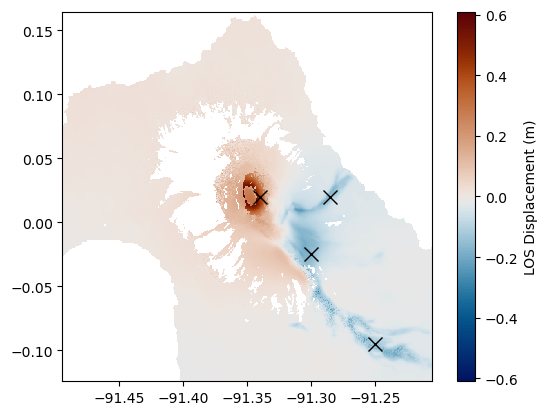

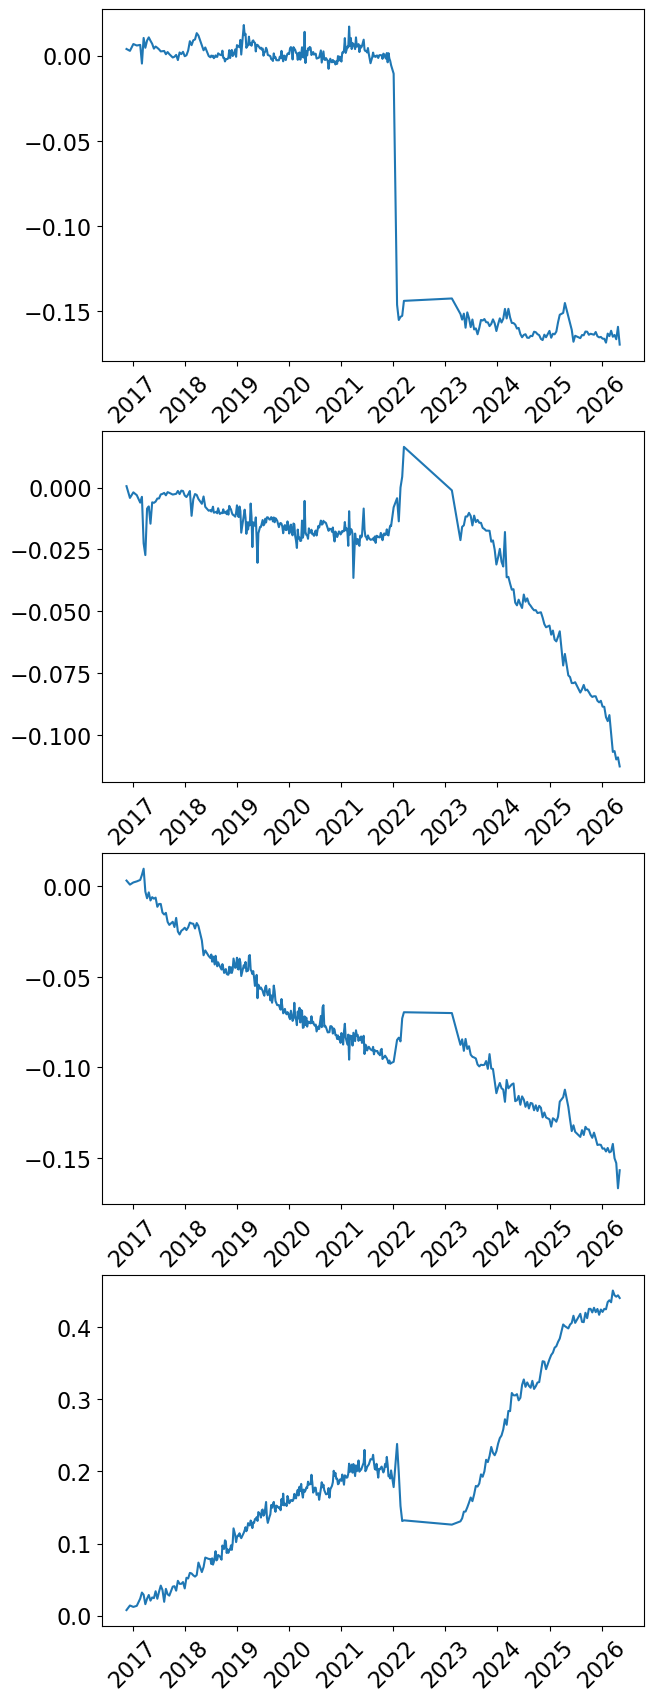

In [2]:
# Specify timeseries files
StorePath = '/work/xfc/vol7/user_cache/benirela/Other/Pedro_TS/'
EndPath = 'Wolf/106A/TS_GEOCml2clipmask/cum_filt.h5'
TS_File = StorePath + EndPath
#TS_File = StorePath + 'Dabbahu/014A/TS_GEOCml2clipmask/cum_filt.h5'

# Open timeseries file
with h5py.File(TS_File, "r") as f:
    ImDates = f["/imdates"][:]
    LOS = f["/cum"][:]
    cLat = f["/corner_lat"][()]
    cLon = f["/corner_lon"][()]
    postLat = f["/post_lat"][()]
    postLon = f["/post_lon"][()]

# Convert dates
DatesDT = pd.to_datetime(ImDates.astype(str), format="%Y%m%d")
days_ = (DatesDT - DatesDT[0]).days.to_numpy()

LOS = LOS.transpose((1, 2, 0))  # Transpose to (lat, lon, time)

# Find extent
endLat = (LOS.shape[0] - 1) * postLat + cLat
endLon = (LOS.shape[1] - 1) * postLon + cLon

# Create lat and lon postings and grids
lat = np.arange(cLat, endLat + postLat/2, postLat)
lon = np.arange(cLon, endLon + postLon/2, postLon)
Lon, Lat = np.meshgrid(lon, lat)

# Covert from mm to m
LOS = LOS / 1000.0

# Find maximum absolute displacement
CumDisp = LOS[:, :, -1]
MaxDisp = np.nanmax(abs(CumDisp))

# Plot Cumulative displacement
fig = plt.figure(1)
pcm = plt.pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
plt.axis('image')
cbar = plt.colorbar(pcm)
cbar.set_label("LOS Displacement (m)")

# Manually plot full TS at key locations (Wolf)
lonQ1 = -91.30 # 2022 Dyke
latQ1 = -0.025
lonQ2 = -91.25 # 2022 flows
latQ2 = -0.095
lonQ3 = -91.285 # 2015 flows
latQ3 = 0.02
lonQ4 = -91.34 # Summit deformation
latQ4 = 0.02

plt.plot(lonQ1, latQ1, "kx", markersize=10)
plt.plot(lonQ2, latQ2, "kx", markersize=10)
plt.plot(lonQ3, latQ3, "kx", markersize=10)
plt.plot(lonQ4, latQ4, "kx", markersize=10)

IdxLon1 = np.nanargmin(np.abs(lon-lonQ1))
IdxLat1 = np.nanargmin(np.abs(lat-latQ1))
IdxLon2 = np.nanargmin(np.abs(lon-lonQ2))
IdxLat2 = np.nanargmin(np.abs(lat-latQ2))
IdxLon3 = np.nanargmin(np.abs(lon-lonQ3))
IdxLat3 = np.nanargmin(np.abs(lat-latQ3))
IdxLon4 = np.nanargmin(np.abs(lon-lonQ4))
IdxLat4 = np.nanargmin(np.abs(lat-latQ4))

fig, axs = plt.subplots(4,1, figsize=(7,21))
axs[0].plot(DatesDT,LOS[IdxLat1,IdxLon1,:])
axs[1].plot(DatesDT,LOS[IdxLat2,IdxLon2,:])
axs[2].plot(DatesDT,LOS[IdxLat3,IdxLon3,:])
axs[3].plot(DatesDT,LOS[IdxLat4,IdxLon4,:])

for ax in axs.flat:
    ax.tick_params(axis='both', labelsize=16)
    ax.tick_params(axis='x', rotation=45)

### Locate Volcano of interest and mask other volcanoes in the frame

Target volcano location found: Wolf
No nearby volcanoes found


Text(0.5, 1.0, 'Target volcano masked')

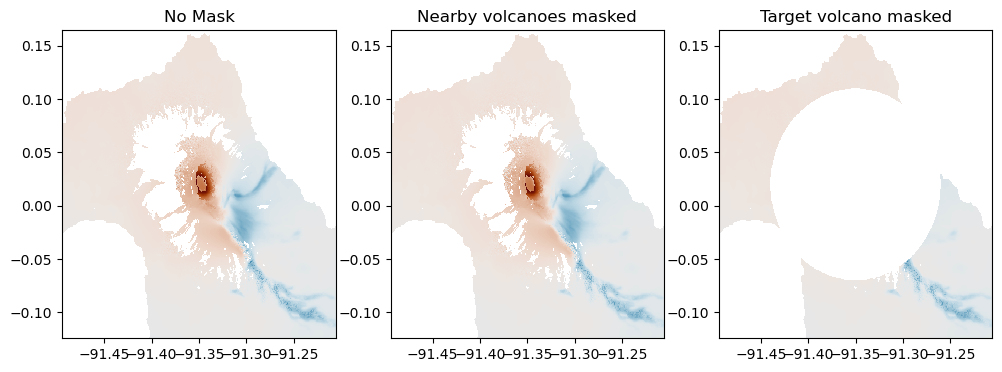

In [3]:
# Load GVP table:
GVP_Tab = '/work/xfc/vol7/user_cache/benirela/Other/GVP/GVP/GVP_Volcano_List_Holocene.xlsx'
GVP = pd.read_excel(GVP_Tab)

# Get volc name
VolcName = EndPath.split('/')[0]
VolcName = VolcName.replace('_', ' ')
#matches = GVP['Volcano Name'].str.contains(VolcName, case=False, na=False)
matches = GVP[GVP.iloc[:,1] == VolcName]
found = (GVP.iloc[:, 1].astype(str) == VolcName).any()

if found:
    print("Target volcano location found: " + VolcName)
else:
    print("No volcano name matching " + VolcName + " found in GVP table.")

# Get volc lat and lon
volcLat = matches.iloc[0, 8]
volcLon = matches.iloc[0, 9]

# Convert lat lon to km for buffering
bufferTargetVolc = 10 # in km
bufferOtherVolcs = 5 # in km
km_per_deg_lat = 111.32
km_per_deg_lon = 111.32 * np.cos(np.radians(volcLat))

volc_xy = np.column_stack([
    volcLon * km_per_deg_lon,
    volcLat * km_per_deg_lat
])

# Convert image pixels to km coordinates
LL_xy = np.column_stack([
    (Lon.ravel() * km_per_deg_lon),
    (Lat.ravel() * km_per_deg_lat)
])

# Use KDTree to find pixels within buffer distance of volcano
LL_tree = cKDTree(LL_xy)
neighbors = LL_tree.query_ball_point(volc_xy, r=bufferTargetVolc)
mask = np.zeros(LOS.shape, dtype=bool)
for idx in neighbors:
    Row, Col = np.unravel_index(idx, (LOS.shape[0], LOS.shape[1]))
    mask[Row, Col, :] = True

LOS_ThisVolc = np.copy(LOS)
LOS_ThisVolc[mask] = np.nan

# Find other volcanoes within the LOS extent + Buffer distance
MaxLon = (np.max(LL_xy[:, 0]) + bufferOtherVolcs)/km_per_deg_lon
MinLon = (np.min(LL_xy[:, 0]) - bufferOtherVolcs)/km_per_deg_lon
MaxLat = (np.max(LL_xy[:, 1]) + bufferOtherVolcs)/km_per_deg_lat
MinLat = (np.min(LL_xy[:, 1]) - bufferOtherVolcs)/km_per_deg_lat

GVP.iloc[:, 8] = pd.to_numeric(GVP.iloc[:, 8], errors="coerce")
GVP.iloc[:, 9] = pd.to_numeric(GVP.iloc[:, 9], errors="coerce")

latStr = GVP.iloc[:, 8]
lonStr = GVP.iloc[:, 9]
name = GVP.iloc[:,1]

# Filter to nearby volcanoes except target
Frame_Volcs = GVP[
    (GVP.iloc[:, 8] >= MinLat) &
    (GVP.iloc[:, 8] <= MaxLat) &
    (GVP.iloc[:, 9] >= MinLon) &
    (GVP.iloc[:, 9] <= MaxLon) &
    (GVP.iloc[:, 1] != VolcName)
]

if not Frame_Volcs.empty:
    print("Nearby volcanoes found:")
    print(Frame_Volcs.iloc[:, 1])
    # Create mask based on nearby volcanoes
    nearVolc_xy = np.column_stack([
        Frame_Volcs.iloc[:, 9] * km_per_deg_lon,
        Frame_Volcs.iloc[:, 8] * km_per_deg_lat
    ])
    neighbors2 = LL_tree.query_ball_point(nearVolc_xy, r=bufferOtherVolcs)
    mask2 = np.zeros(LOS.shape, dtype=bool)
    for idx in neighbors2:
        Row, Col = np.unravel_index(idx, (LOS.shape[0], LOS.shape[1]))
        mask2[Row, Col, :] = True

    LOS_NeabyVolcs = np.copy(LOS)
    LOS_NeabyVolcs[mask2] = np.nan
else:
    print("No nearby volcanoes found")
    LOS_NeabyVolcs = np.copy(LOS)

# Visualise masks
fig, axs = plt.subplots(1,3, figsize=(12, 4))
pcm = axs[0].pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[0].set_title("No Mask")

pcm = axs[1].pcolormesh(
    Lon,
    Lat,
    LOS_NeabyVolcs[:, :, -1],
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[1].set_title("Nearby volcanoes masked")

pcm = axs[2].pcolormesh(
    Lon,
    Lat,
    LOS_ThisVolc[:, :, -1],
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[2].set_title("Target volcano masked")

### Determine signal-noise ratio

In [4]:
# Define SNR function
def get_SNR(fullData, maskData, binWidth):
    maxD = np.nanmax(np.abs(fullData))
    # Plot histogram of temporal noise across each step outside the target volcano mask
    temporal_noise = np.nanstd(maskData, axis=2)
    temporal_noise = temporal_noise.flatten()
    temporal_noise = temporal_noise[~np.isnan(temporal_noise)]

    # Plot histogram of temporal noise
    binEdges = np.arange(-1,1,binWidth)
    counts, edges = np.histogram(temporal_noise, bins=binEdges)

    # Get bin with maximum count
    edge_max1 = edges[np.argmax(counts)]
    edge_max2 = edge_max1 + binWidth

    # Get mean of those in max bin
    Noise = np.mean(temporal_noise[(temporal_noise >= edge_max1) & (temporal_noise < edge_max2)])
    SNR = maxD/Noise
    return SNR, maxD, Noise, counts, edges, temporal_noise

Temporal noise: 0.75 cm
Max. Signal: 61.58 cm
Signal-to-noise ratio: 81.87


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


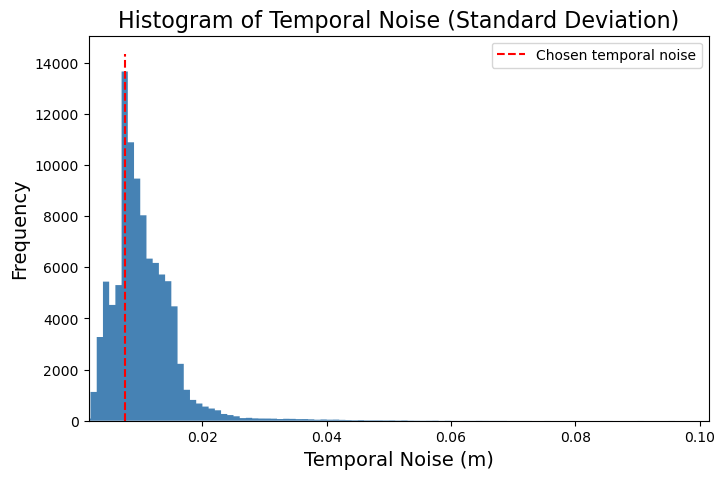

In [5]:
binW = 0.001 # Bin width in meters (1 mm)
SNR, max_disp_all, Noise, counts, edges, temporal_noise = get_SNR(LOS,LOS_ThisVolc,binW)

print('Temporal noise: ' + str(round(Noise*100, 2)) + ' cm')
print('Max. Signal: ' + str(round(max_disp_all*100, 2)) + ' cm')
print('Signal-to-noise ratio: ' + str(round(SNR, 2)))
FullSNR = SNR

fig, ax = plt.subplots(1,1, figsize=(8, 5))
ax.stairs(counts, edges, fill=True, color='steelblue', edgecolor='black')
ax.set_title('Histogram of Temporal Noise (Standard Deviation)', fontsize=16)
ax.set_xlabel('Temporal Noise (m)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_xlim(min(temporal_noise), max(temporal_noise))
ax.vlines(Noise, plt.ylim()[0], plt.ylim()[1], color='red', linestyle='--', label='Chosen temporal noise')
ax.legend()

## Methods - Determine how many signals and deformation centres

In [6]:
SNRThresh = 3
SNRThresh_maybe = 2
T_winsize = 1 # Timeseries window size in years
if SNR > SNRThresh:
    print("SNR is greater than " + str(SNRThresh) + ", looking for signals")
    
    # Get timeseries indexes to query
    yrs = days_ / 365.25
    TS_Len = yrs[-1]
    yrsQ = np.arange(T_winsize,np.ceil(TS_Len),T_winsize)
    
    idxYrs = np.empty((len(yrsQ),1))
    idxYrs.fill(np.nan)
    for i , j in enumerate(yrsQ):
        idxYrs[i] = np.argmin(abs(yrs-j))
    idxYrs = idxYrs.astype(int).flatten()

    # Calculate SNR at every T_winsize in the dataset and index of biggest point
    Set_SNR = np.empty((len(yrsQ),1))
    Set_SNR.fill(np.nan)
    Set_maxD = Set_SNR.copy()
    Set_Noise = Set_SNR.copy()
    Set_SNR_Inc = Set_SNR.copy()
    Set_maxD_Inc = Set_SNR.copy()
    Set_Noise_Inc = Set_SNR.copy()
    RowIdx = Set_SNR.copy()
    ColIdx = Set_SNR.copy()
    TimeIdx = Set_SNR.copy()
    RowIdxInc = Set_SNR.copy()
    ColIdxInc = Set_SNR.copy()
    TimeIdxInc = Set_SNR.copy()
    StartIdx = Set_SNR.copy()
    StartYr = Set_SNR.copy()
    EndYr = Set_SNR.copy()

    for i in range(len(yrsQ)):
        if i==0:
            # Extract cumulative disp. during timeperiod X-Y
            Set_CumDisp = LOS[:,:,0:idxYrs[i]]
            Set_CumDispMask = LOS_ThisVolc[:,:,0:idxYrs[i]]

            Set_IncDisp = Set_CumDisp.copy()
            Set_IncDispMask = Set_CumDispMask.copy()

            StartIdx[i] = 0
        else:
            # Extract cumulative disp. during timeperiod X-Y
            Set_CumDisp = LOS[:,:,idxYrs[i-1]:idxYrs[i]]
            Set_CumDispMask = LOS_ThisVolc[:,:,idxYrs[i-1]:idxYrs[i]]

            # Extract stepwise disp. during timeperiod X-Y
            Set_IncDisp = LOS[:,:,idxYrs[i-1]:idxYrs[i]] - LOS[:,:,idxYrs[i-1]][:, :, None]
            Set_IncDispMask = LOS_ThisVolc[:,:,idxYrs[i-1]:idxYrs[i]] - LOS_ThisVolc[:,:,idxYrs[i-1]][:, :, None]

            StartIdx[i] = idxYrs[i-1]

        # Get spatial and temporal location of highest displacement during the timeperiod
        RowIdx[i], ColIdx[i], TimeIdx[i] = np.unravel_index(np.nanargmax(np.abs(Set_CumDisp)), Set_CumDisp.shape)
        RowIdxInc[i], ColIdxInc[i], TimeIdxInc[i] = np.unravel_index(np.nanargmax(np.abs(Set_IncDisp)), Set_IncDisp.shape)
        TimeIdx[i] = TimeIdx[i] + StartIdx[i]
        TimeIdxInc[i] = TimeIdxInc[i] + StartIdx[i]
        StartYr[i] = i-1
        EndYr[i] = i
        # Get SNR
        Set_SNR[i], Set_maxD[i], Set_Noise[i], _, _, _ = get_SNR(Set_CumDisp,Set_CumDispMask,binW)
        Set_SNR_Inc[i], Set_maxD_Inc[i], Set_Noise_Inc[i], _, _, _ = get_SNR(Set_IncDisp,Set_IncDispMask,binW)
    

    
elif SNR > SNRThresh_maybe:
    print("SNR is greater than " + str(SNRThresh_maybe) + ", but not greater than " + str(SNRThresh) + ", may be looking for signals")

else:
    print("SNR is less than or equal to " + str(SNRThresh_maybe) + ", likely no signals above noise level")


SNR is greater than 3, looking for signals


### Visualise biggest deformation points in different timeperiods

Text(0.5, 0.98, 'Cumulative displacements')

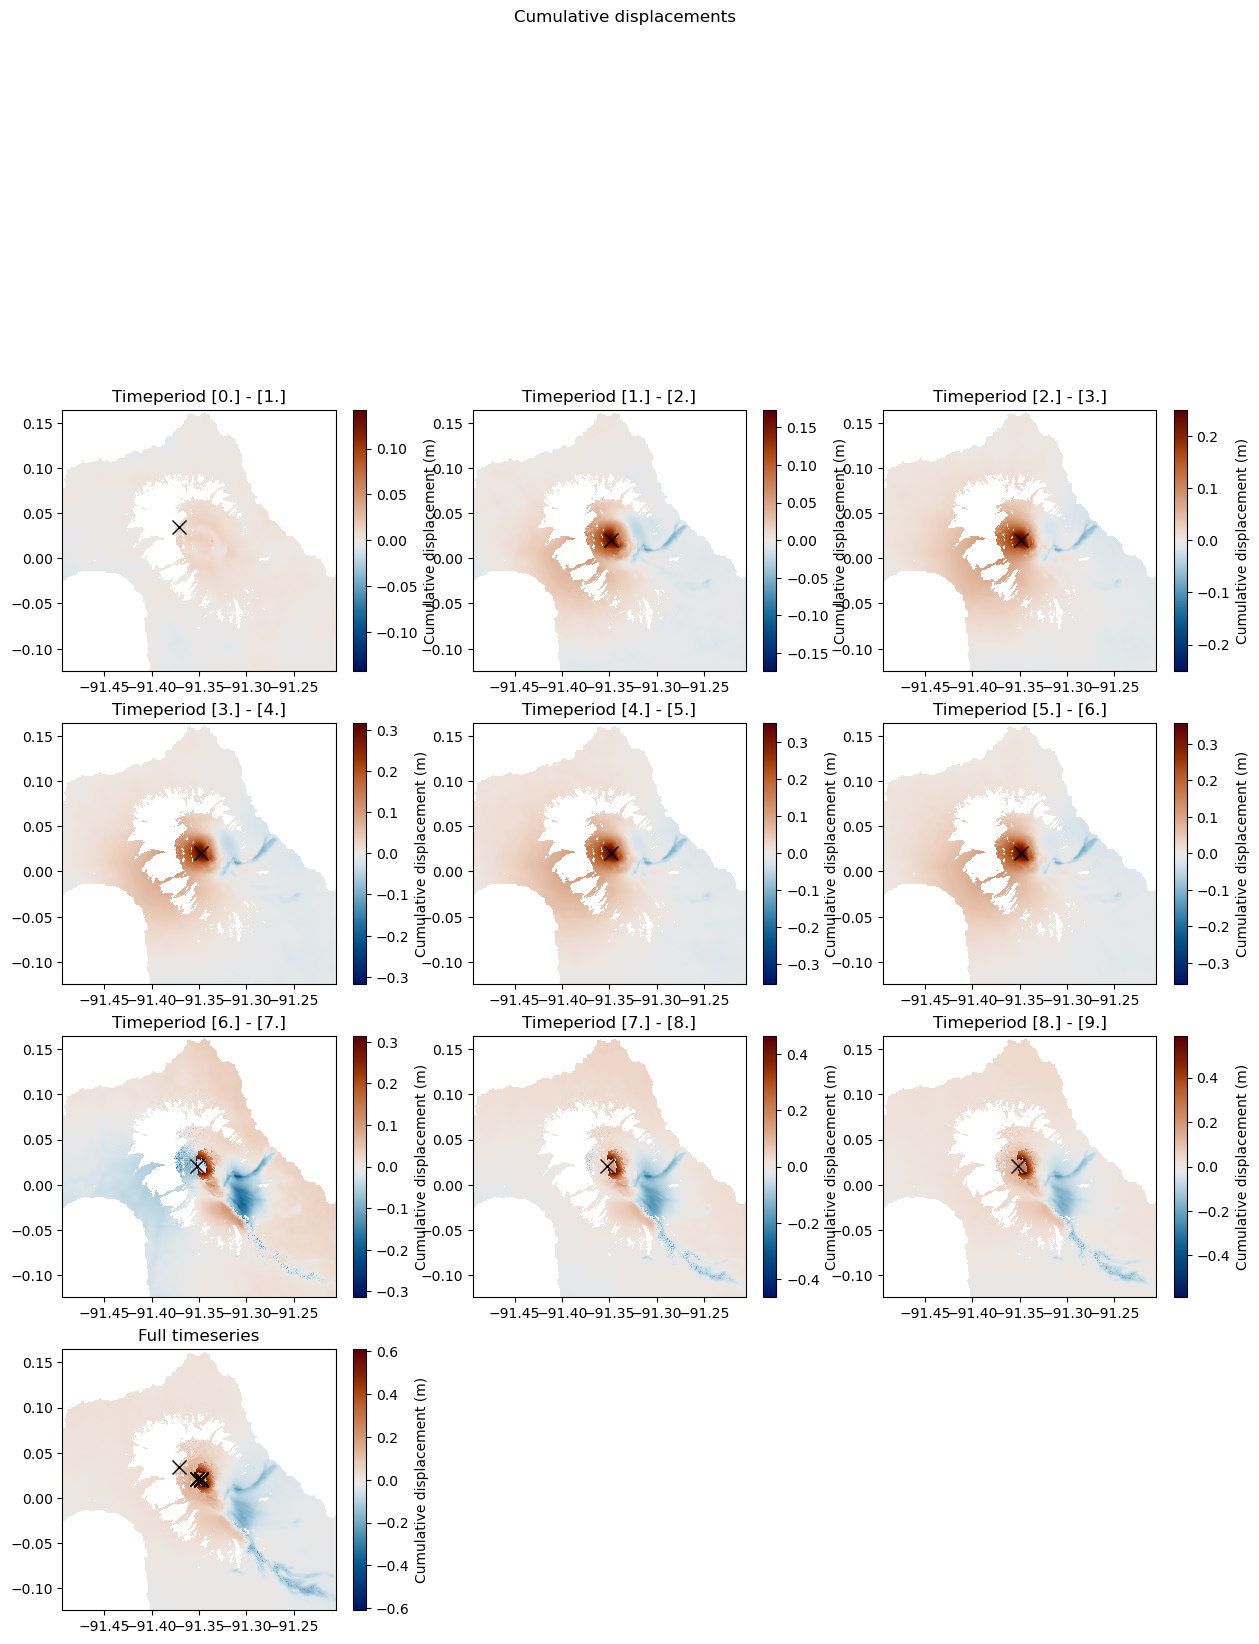

In [7]:
# Plot outputs of SNR tests
numCols = 3
numRows = np.ceil(len(yrsQ)+1/numCols).astype(int)
fig, axs = plt.subplots(numRows,numCols, figsize=(15,40))

TimeIdx = TimeIdx.astype(int).flatten()
RowIdx = RowIdx.astype(int).flatten()
ColIdx = ColIdx.astype(int).flatten()
StartIdx = StartIdx.astype(int).flatten()

nplots = len(yrsQ) + 1  # +1 for full timeseries
total_slots = numRows * numCols

for k in range(min(nplots, total_slots)):

    i, j = divmod(k, numCols)

    # Choose data
    if k == len(yrsQ):
        Disp = CumDisp.copy()
        title = "Full timeseries"
        x = Lon[RowIdx, ColIdx]
        y = Lat[RowIdx, ColIdx]
    else:
        Disp = LOS[:, :, TimeIdx[k]]
        title = f"Timeperiod {StartYr[k]+1} - {EndYr[k]+1}"
        x = Lon[RowIdx[k], ColIdx[k]]
        y = Lat[RowIdx[k], ColIdx[k]]

    # Plot field
    pcm = axs[i, j].pcolormesh(
        Lon,
        Lat,
        Disp,
        shading="auto",
        cmap=cm.vik,
        vmax=np.nanmax(abs(Disp)),
        vmin=-np.nanmax(abs(Disp))
    )

    axs[i, j].set_title(title)

    # Colorbar (per subplot, same as your original logic)
    cbar = plt.colorbar(pcm, ax=axs[i, j])
    cbar.set_label("Cumulative displacement (m)")

    # Marker
    axs[i, j].plot(x, y, "kx", markersize=10)

for k in range(nplots, total_slots):
    i, j = divmod(k, numCols)
    axs[i, j].set_visible(False)

plt.suptitle("Cumulative displacements")

### Step-wise displacements

In [1]:
# Plot outputs of SNR tests
numCols = 3
numRows = np.ceil(len(yrsQ)+1/numCols).astype(int)
fig, axs = plt.subplots(numRows,numCols, figsize=(15, 40))

TimeIdxInc = TimeIdxInc.astype(int).flatten()
RowIdxInc = RowIdxInc.astype(int).flatten()
ColIdxInc = ColIdxInc.astype(int).flatten()
StartIdx = StartIdx.astype(int).flatten()

nplots = len(yrsQ) + 1  # +1 for full timeseries
total_slots = numRows * numCols

Disp_Steps = np.empty([LOS.shape[0],LOS.shape[1],len(yrsQ)])

for k in range(min(nplots, total_slots)):

    i, j = divmod(k, numCols)

    # Choose data
    if k == len(yrsQ):
        Disp = CumDisp.copy()
        title = "Full timeseries"
        x = Lon[RowIdxInc, ColIdxInc]
        y = Lat[RowIdxInc, ColIdxInc]
    else:
        Disp = LOS[:, :, TimeIdxInc[k]] - LOS[:,:, StartIdx[k]]
        title = f"Years {StartYr[k]+1} - {EndYr[k]+1}"
        x = Lon[RowIdxInc[k], ColIdxInc[k]]
        y = Lat[RowIdxInc[k], ColIdxInc[k]]

        Disp_Steps[:,:,k] = Disp

    # Plot field
    pcm = axs[i, j].pcolormesh(
        Lon,
        Lat,
        Disp,
        shading="auto",
        cmap=cm.vik,
        vmax=np.nanmax(abs(Disp)),
        vmin=-np.nanmax(abs(Disp))
    )

    axs[i, j].set_title(title)

    # Colorbar (per subplot, same as your original logic)
    cbar = plt.colorbar(pcm, ax=axs[i, j])
    cbar.set_label("Cumulative displacement (m)")

    # Marker
    axs[i, j].plot(x, y, "kx", markersize=10)

for k in range(nplots, total_slots):
    i, j = divmod(k, numCols)
    axs[i, j].set_visible(False)

plt.suptitle("Stepwise displacements")

NameError: name 'np' is not defined

In [9]:
# Step-wise displacements again
for i in range(Disp_Steps.shape[2]):
    print(i)

0
1
2
3
4
5
6
7
8


### Methods - Cluster deformation centres

## Methods - deformation centre - smoothing

Text(0.5, 1.0, 'Smoothed cumulative displacement (Sigma = 1)')

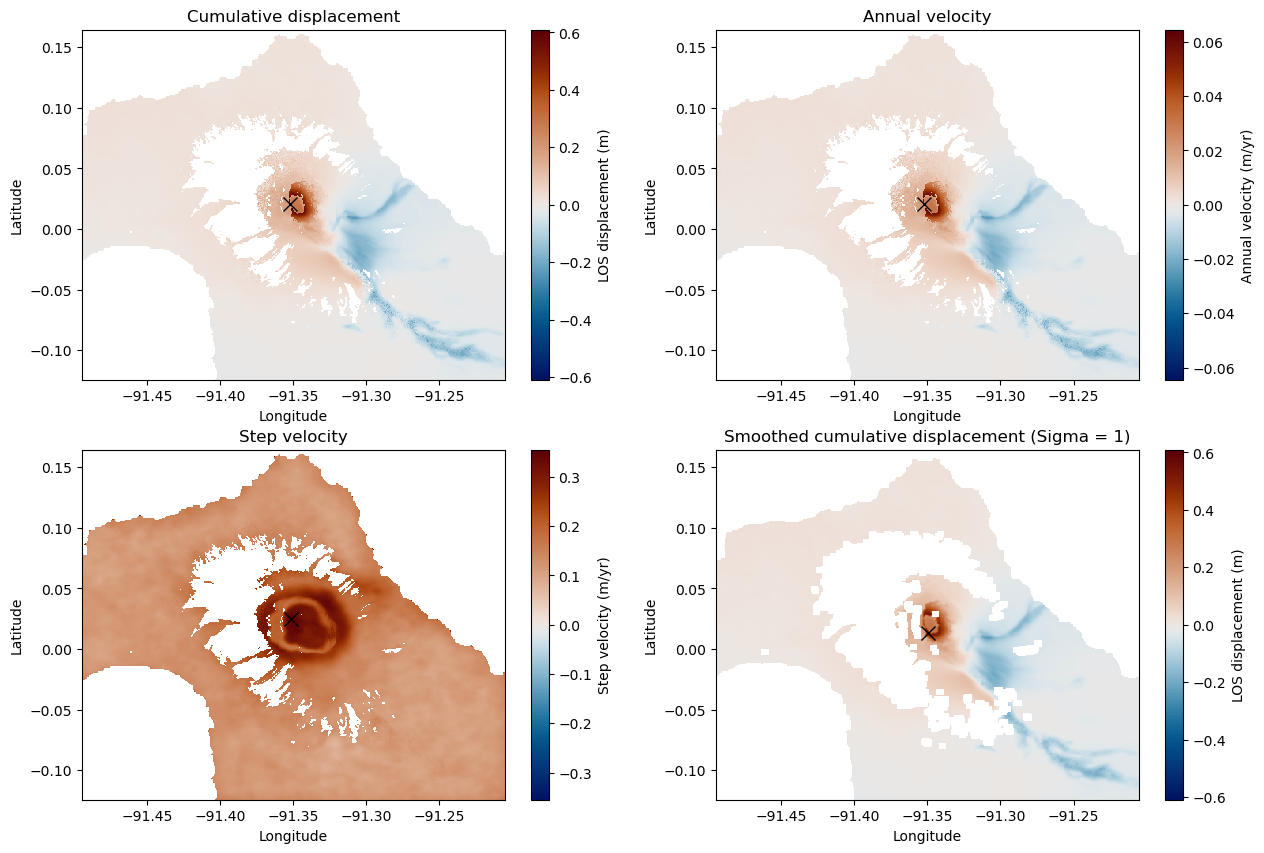

In [10]:
# Work out annual velocity
VelAnn = CumDisp / (days_[-1] / 365.25)

# Work out average absolute velocity between all timesteps at all pixels
VelStep = np.full(CumDisp.shape, np.nan, dtype=float)
for i in range(LOS.shape[0]):
    for j in range(LOS.shape[1]):
        if np.isnan(LOS[i,j,0]):
            VelStep[i, j] = np.nan
        else:
            VelStep[i, j] = np.nanmean(np.abs(np.diff(LOS[i, j, :]) / np.diff(days_ / 365.25)))

# Get locations
Idx_MaxD = np.nanargmax(abs(CumDisp))
Idx_MaxD_Lat, Idx_MaxD_Lon = np.unravel_index(Idx_MaxD, CumDisp.shape)
Idx_MaxVa = np.nanargmax(abs(VelAnn))
Idx_MaxVa_Lat, Idx_MaxVa_Lon = np.unravel_index(Idx_MaxVa, VelAnn.shape)
Idx_MaxVs = np.nanargmax(abs(VelStep))
Idx_MaxVs_Lat, Idx_MaxVs_Lon = np.unravel_index(Idx_MaxVs, VelStep.shape)

MaxVelA = np.nanmax(abs(VelAnn))
MaxVelS = np.nanmax(abs(VelStep))

# Try different filters for smoothing
sigma = 1
CumDisp_Smooth = filters.gaussian(CumDisp, sigma=sigma)
Idx_MaxDS = np.nanargmax(abs(CumDisp_Smooth))
Idx_MaxDS_Lat, Idx_MaxDS_Lon = np.unravel_index(Idx_MaxDS, CumDisp_Smooth.shape)

# Plot cumulative displacement and velocities
fig, axs = plt.subplots(2,2, figsize=(15, 10))

pcm = axs[0,0].pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)

cbar = plt.colorbar(pcm, ax=axs[0,0])
cbar.set_label("LOS displacement (m)")
axs[0,0].set_xlabel("Longitude")
axs[0,0].set_ylabel("Latitude")
axs[0,0].set_title("Cumulative displacement")

PLT = axs[0,0].plot(Lon[Idx_MaxD_Lat, Idx_MaxD_Lon], Lat[Idx_MaxD_Lat, Idx_MaxD_Lon], "kx", markersize=10, label="Max cumulative displacement")

pcm = axs[0,1].pcolormesh(
    Lon,
    Lat,
    VelAnn,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxVelA,
    vmin=-MaxVelA   
)

cbar = plt.colorbar(pcm, ax=axs[0,1])
cbar.set_label("Annual velocity (m/yr)")
axs[0,1].set_xlabel("Longitude")
axs[0,1].set_ylabel("Latitude")
axs[0,1].set_title("Annual velocity")

PLT = axs[0,1].plot(Lon[Idx_MaxVa_Lat, Idx_MaxVa_Lon], Lat[Idx_MaxVa_Lat, Idx_MaxVa_Lon], "kx", markersize=10, label="Max annual velocity")

pcm = axs[1,0].pcolormesh(
    Lon,
    Lat,
    VelStep,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxVelS,
    vmin=-MaxVelS
)

cbar = plt.colorbar(pcm, ax=axs[1,0])
cbar.set_label("Step velocity (m/yr)")
axs[1,0].set_xlabel("Longitude")
axs[1,0].set_ylabel("Latitude")
axs[1,0].set_title("Step velocity")

PLT = axs[1,0].plot(Lon[Idx_MaxVs_Lat, Idx_MaxVs_Lon], Lat[Idx_MaxVs_Lat, Idx_MaxVs_Lon], "kx", markersize=10, label="Max step velocity")

pcm = axs[1,1].pcolormesh(
    Lon,
    Lat,
    CumDisp_Smooth,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)

PLT = axs[1,1].plot(Lon[Idx_MaxDS_Lat, Idx_MaxDS_Lon], Lat[Idx_MaxDS_Lat, Idx_MaxDS_Lon], "kx", markersize=10, label="Max smoothed cumulative displacement")

cbar = plt.colorbar(pcm, ax=axs[1,1])
cbar.set_label("LOS displacement (m)")
axs[1,1].set_xlabel("Longitude")
axs[1,1].set_ylabel("Latitude")
axs[1,1].set_title(f"Smoothed cumulative displacement (Sigma = {sigma})")

### Methods - deformation centre - Watershed segmentation and Peak identification

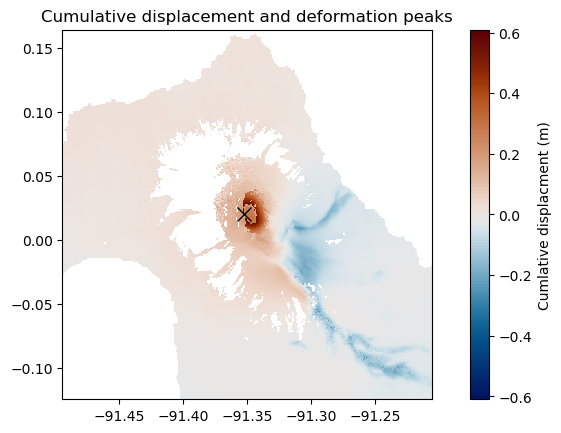

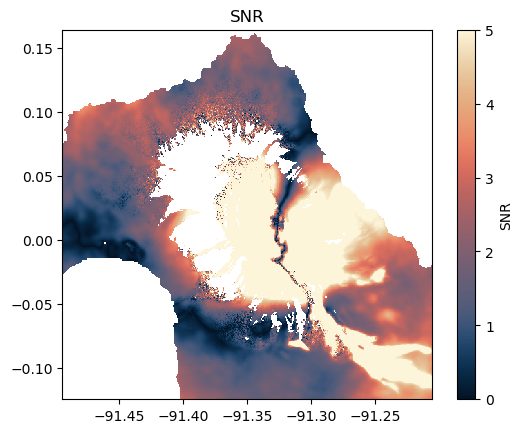

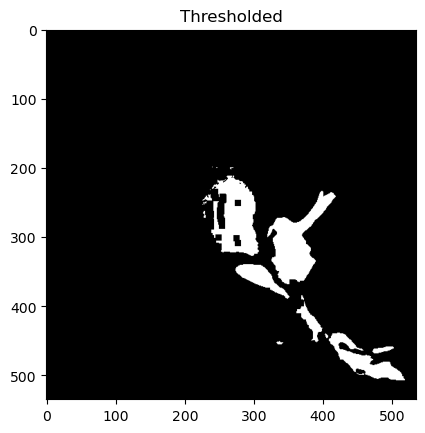

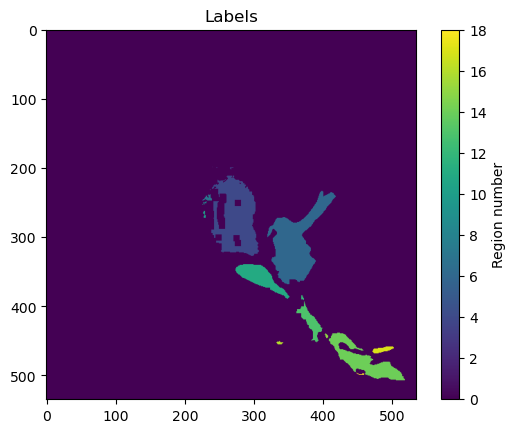

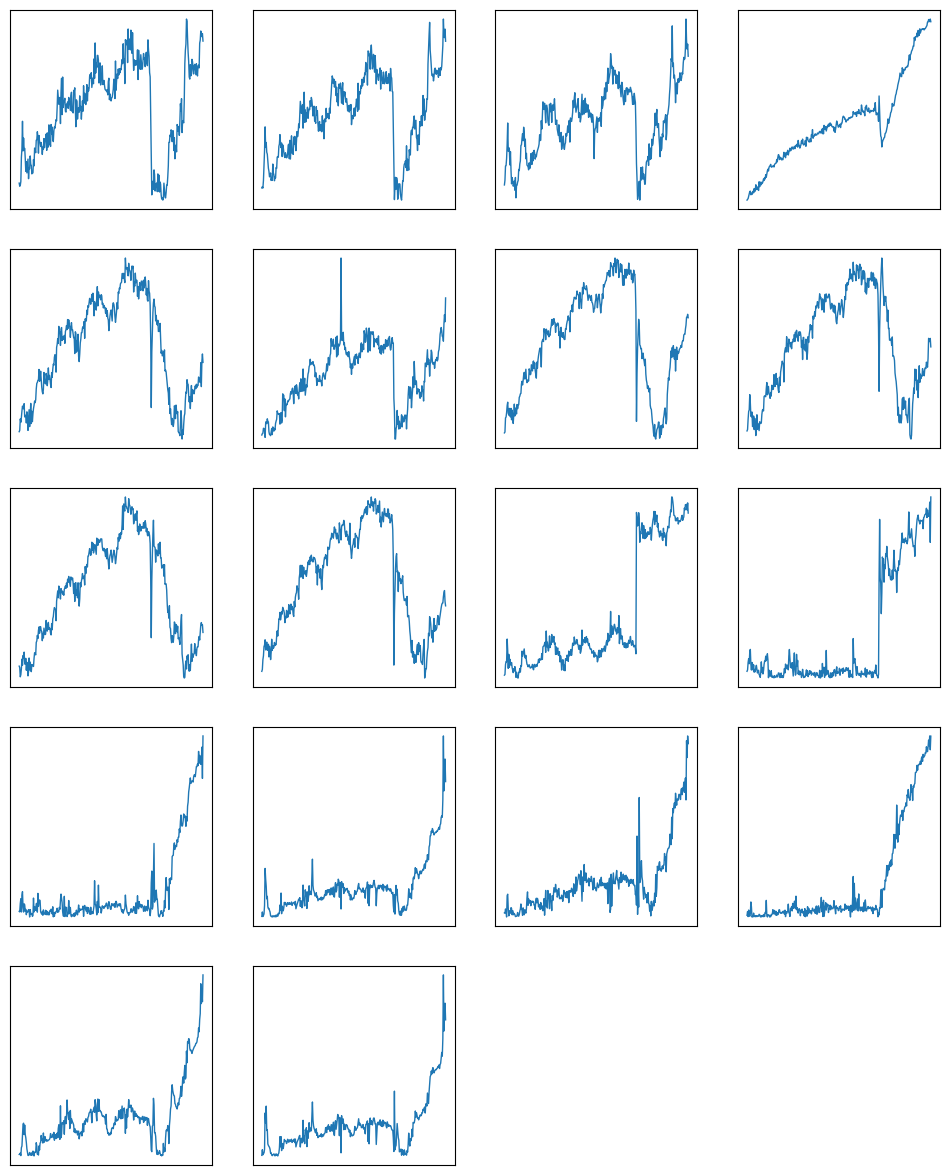

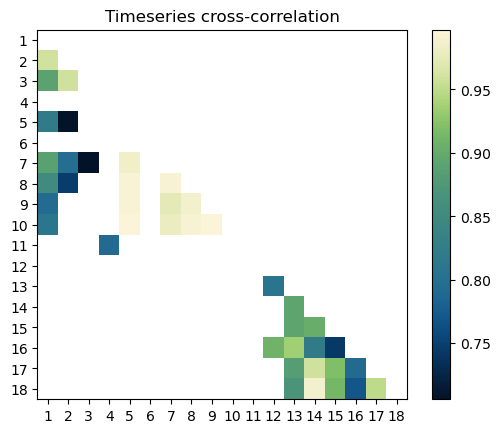

In [ ]:
spatialRes_m = 30
min_radius_km = 3
min_dist = round((min_radius_km*1000)/spatialRes_m)
mask = np.isfinite(CumDisp_Smooth) # Mask NaN values
Im_SNR = np.abs(CumDisp)/Noise
Im_SNR_Smooth = np.abs(CumDisp_Smooth)/Noise

coordinates = peak_local_max(CumDisp_Smooth,min_distance=min_dist,threshold_abs=SNRThresh*Noise,labels=mask.astype(int))
coordinates = peak_local_max(CumDisp,min_distance=min_dist,threshold_abs=SNRThresh*Noise,labels=mask.astype(int))

fig = plt.figure(1)
pcm = plt.pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
cbar = plt.colorbar(pcm)
cbar.set_label("Cumlative displacment (m)")
plt.plot(Lon[coordinates[:,0], coordinates[:,1]], Lat[coordinates[:,0], coordinates[:,1]], "kx", markersize=10, label="Local maxima")
plt.axis('image')
plt.title('Cumulative displacement and deformation peaks')

fig = plt.figure(2)
pcm = plt.pcolormesh(
    Lon,
    Lat,
    np.abs(CumDisp)/Noise,
    shading="auto",
    cmap=cm.lipari,
    vmax=5,
    vmin=0
)
plt.axis('image')
cbar = plt.colorbar(pcm)
cbar.set_label("SNR")
plt.title('SNR')

# Test applying Otsu thresholding
sigma = 1
CumDisp_Smooth2 = filters.gaussian(CumDisp, sigma=sigma)
Img = (np.abs(CumDisp_Smooth2)/np.nanmax(np.abs(CumDisp_Smooth2)))*255
Img = np.nan_to_num(Img, False, 0)

Img_Thresh = filters.threshold_otsu(Img)
binary = Img > Img_Thresh

fig = plt.figure(3)
plt.imshow(binary, cmap=plt.cm.gray)
plt.title('Thresholded')

# Identify objects from thresholding and merge based on temporal cross-correlation
# Find conncected regions in binary output
Labels = measure.label(binary,connectivity=2)
fig = plt.figure(4)
Img = plt.imshow(Labels)
plt.title('Labels')
cbar = plt.colorbar(Img)
cbar.set_label("Region number")

numRegions = len(np.unique(Labels)) - 1 # To remove label 0 for background

# For each region, get max abs displacement pixel timeseries
winSize = 5 # in pixels
MeanTS = np.empty((numRegions,LOS.shape[2]))

for k in range(1,numRegions + 1):
    coords = np.where(Labels == k)
    max_pos = np.argmax(CumDisp_Smooth2[coords])
    row = coords[0][max_pos]
    col = coords[1][max_pos]

    # TODO - add edge-cases for edge of image
    rows = range((row-round(winSize/2)),(row+round(winSize/2)))
    cols = range((col-round(winSize/2)),(col+round(winSize/2)))
    PixelTS = LOS[rows,cols,:]

    MeanTS[k-1,:] = np.nanmean(PixelTS,axis=0)

# Visualise pixel timeseries from each region
MeanTS = MeanTS / np.max(MeanTS, axis=1, keepdims=True) # Normalise

n_rows = MeanTS.shape[0]
n_cols = 4
n_plot_rows = int(np.ceil(n_rows / n_cols))

fig, axes = plt.subplots(
    n_plot_rows,
    n_cols,
    figsize=(12, 3 * n_plot_rows)
)

axes = axes.ravel()

FiltSize = 3
mean_kernel2 = np.full((FiltSize,), 1/FiltSize)
for i in range(n_rows):
    ax = axes[i]
    ax.plot(abs(MeanTS[i]), lw=1)

    # Remove tick marks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove axis labels and title
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')

# Remove unused subplots
for i in range(n_rows, len(axes)):
    fig.delaxes(axes[i])

# Run cross-correlations between the timeseries
Cross_Corr = np.empty((n_rows,n_rows))
for i in range(n_rows):
    for j in range(n_rows):
        if i<j:
            Cross_Corr[i,j] = np.nan
        elif i==j:
            Cross_Corr[i,j] = np.nan
        else:
            Cross_Corr[i,j] = np.corrcoef(MeanTS[i,:],MeanTS[j,:])[0,1]

# Visualise cross-correlations
fig = plt.figure(6)
cutoff = 0.7

Cross_Corr_masked = np.ma.masked_less(Cross_Corr, cutoff)
cc = plt.imshow(Cross_Corr_masked, cmap=cm.navia)
plt.title('Timeseries cross-correlation')
plt.xticks(range(n_rows),range(1,n_rows+1))
plt.yticks(range(n_rows),range(1,n_rows+1))
cbar = plt.colorbar(cc)

# Run cross-correlations if some timeseries are not correlated with each other

# def correlation_cliques(corr_matrix, cutoff):
#     n = corr_matrix.shape[0]

#     G = nx.Graph()
#     G.add_nodes_from(range(n))

#     for i in range(n):
#         for j in range(i + 1, n):
#             if corr_matrix[i, j] >= cutoff:
#                 G.add_edge(i, j)

#     return list(nx.find_cliques(G))

# groups = correlation_cliques(Cross_Corr, cutoff)
# print(groups)

# Cluster timeseries to merge connected regions
# dist_vec = 1 - Cross_Corr
# np.fill_diagonal(dist_vec, 0)
# #dist_vec = dist_vec.reshape(-1, 1) 
# cutoff = 0.9
# AggClust = AgglomerativeClustering(n_clusters=None,compute_distances=False,distance_threshold=1-cutoff,linkage='complete')
# TS_Labels = AggClust.fit_predict(dist_vec)


k=2, silhouette=0.3354
k=3, silhouette=0.3432
k=4, silhouette=0.4357
k=5, silhouette=0.4972
k=6, silhouette=0.3379
k=7, silhouette=0.2849
k=8, silhouette=0.2225

Best k: 5 (silhouette=0.4972)

Cluster assignments:
[1 1 1 4 2 5 2 2 2 2 4 3 5 5 5 3 5 5]


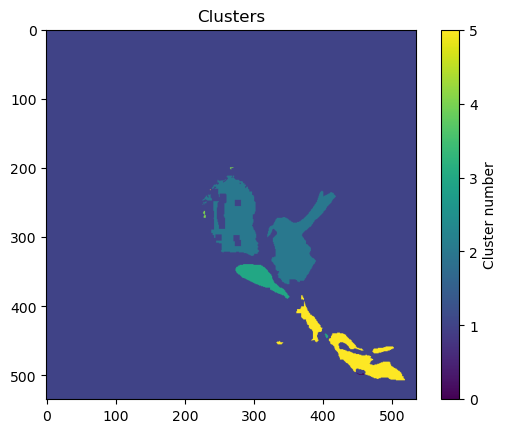

In [12]:
def normalize_timeseries(X):
    """
    X: (n_series, n_timesteps)
    Returns z-normalized version required for KShape.
    """
    scaler = TimeSeriesScalerMeanVariance(mu=0., std=1.)
    return scaler.fit_transform(X)  # returns shape (n, m, 1)


def compute_silhouette(X, labels):
    """
    Silhouette score for time series clustering.
    We flatten because silhouette expects 2D input.
    """
    X_flat = X.squeeze()  # (n, m)
    return silhouette_score(X_flat, labels, metric="euclidean")


def find_best_kshape(X, k_min=2, k_max=10, random_state=0):
    """
    Searches for best number of clusters using silhouette score.
    """
    X_scaled = normalize_timeseries(X)

    best_k = None
    best_score = -1
    best_model = None

    scores = {}

    for k in range(k_min, k_max + 1):
        model = KShape(n_clusters=k, random_state=random_state)
        labels = model.fit_predict(X_scaled)

        score = compute_silhouette(X_scaled, labels)
        scores[k] = score

        print(f"k={k}, silhouette={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_model = model

    print(f"\nBest k: {best_k} (silhouette={best_score:.4f})")

    return best_model, best_k, scores


X = MeanTS
model, best_k, scores = find_best_kshape(X, k_min=2, k_max=8)
labels = model.predict(normalize_timeseries(X))
labels = labels + 1 # To start with base 1
print("\nCluster assignments:")
print(labels)

cluster_map = np.zeros(Labels.shape, dtype=int) 
for i in range(n_rows):
    Idx = Labels == i
    cluster_map[Idx] = labels[i]

fig = plt.figure(8)
Img = plt.imshow(cluster_map)
plt.title('Clusters')
cbar = plt.colorbar(Img)
cbar.set_label("Cluster number")


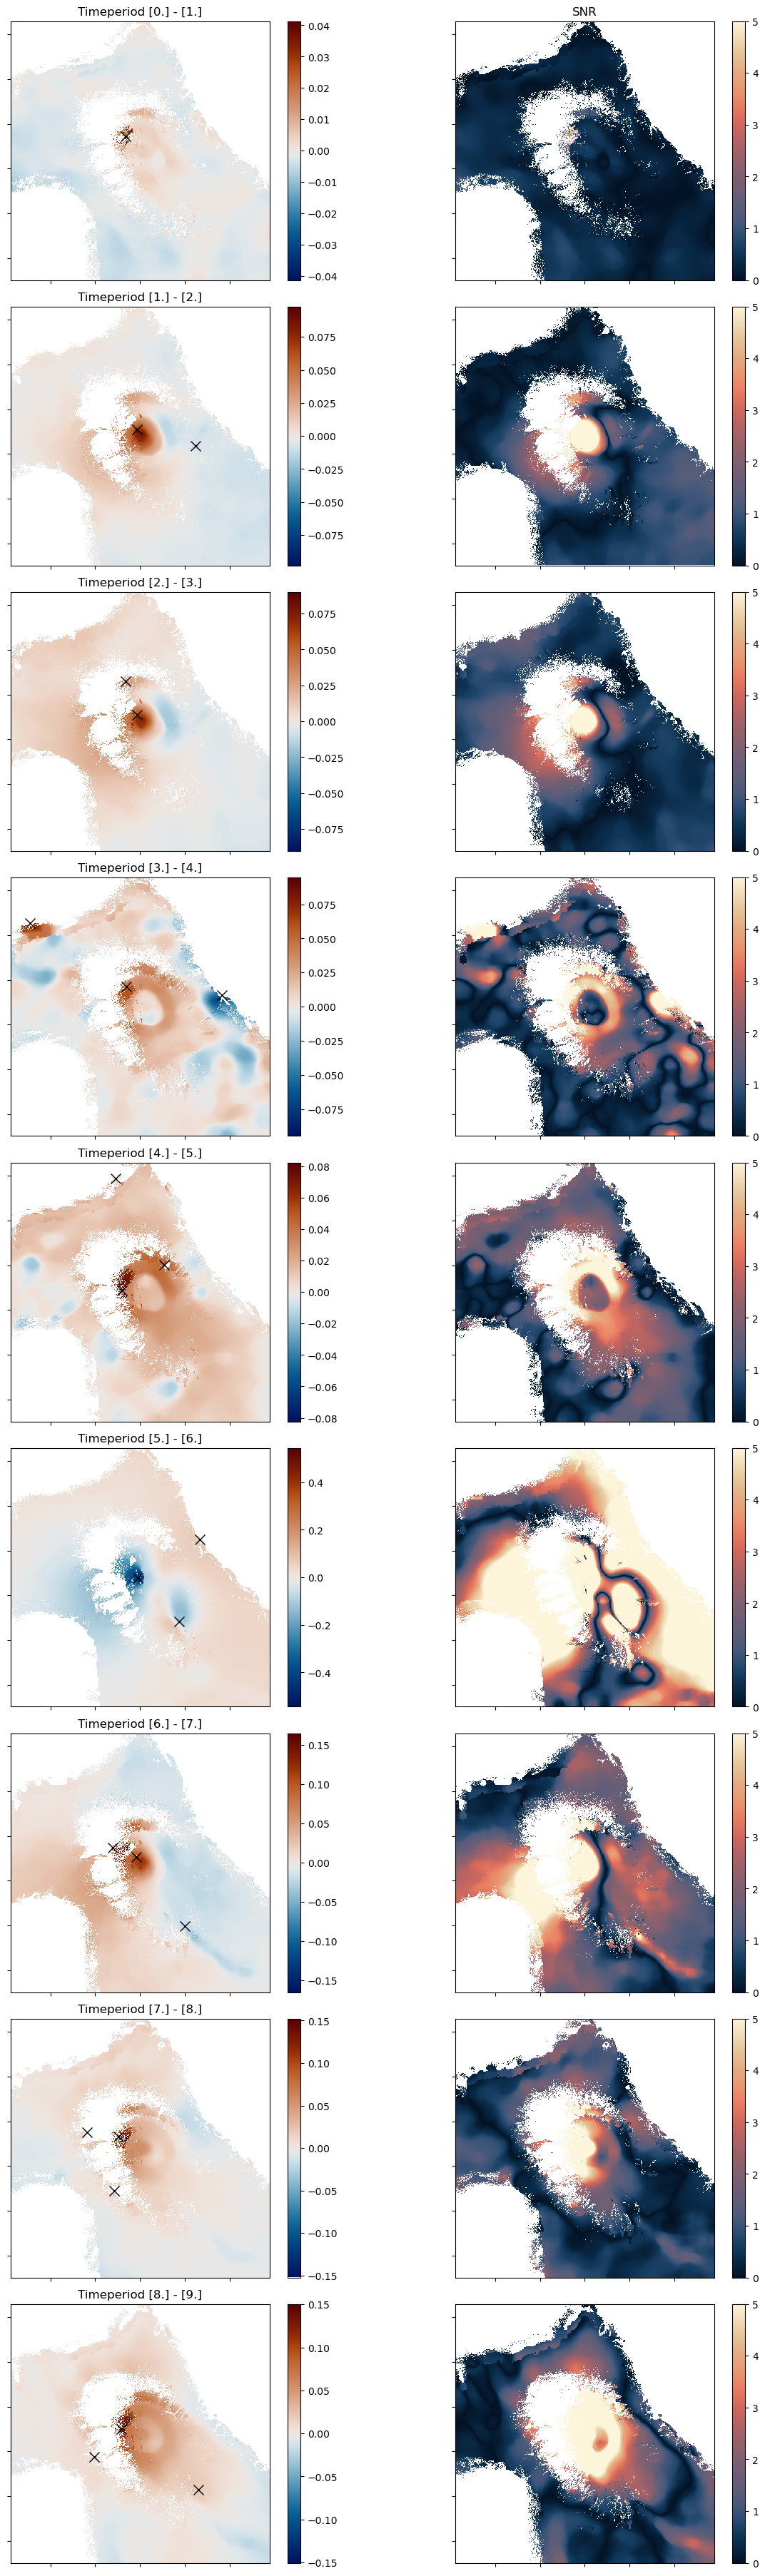

In [ ]:
nRows = Disp_Steps.shape[2]
spatialRes_m = 30
min_radius_km = 1
min_dist = round((min_radius_km*1000)/spatialRes_m)

fig, axs = plt.subplots(
    nRows,
    2,
    figsize=(12, 4 * nRows),
    constrained_layout=True
)

# Handle the case nRows == 1
if nRows == 1:
    axs = axs[np.newaxis, :]

coordinates_all = []
coords_snr = []
YrsFound = []
#Er_radius = 5
for k in range(nRows):

    CumDispInc = Disp_Steps[:, :, k]
    #CumDispInc = filters.gaussian(CumDispInc, sigma=sigma)
    #CumDispInc = filters.gaussian(CumDispInc, sigma=1)
    # Median filter
    CumDispInc = ndi.median_filter(CumDispInc, size=min_dist)

    # # Apply erosion filter and mask
    # binary_img = (~np.isnan(CumDispInc)).astype(np.uint8)
    # eroded = ndi.binary_erosion(binary_img,structure=morphology.disk(Er_radius))
    # eroded = eroded.astype(np.uint8)
    # CumDispInc[eroded == 0] = np.nan
    
    MaskNew = np.isfinite(CumDispInc)
    MaxDispInc = np.nanmax(np.abs(CumDispInc))
    snr = np.abs(CumDispInc) / Noise

    sx = ndi.sobel(CumDispInc,axis=0,mode='constant')
    # Get y-gradient in "sy"
    sy = ndi.sobel(CumDispInc,axis=1,mode='constant')
    # Get square root of sum of squares
    sobel=np.hypot(sx,sy)

    coordinates = peak_local_max(
        np.abs(CumDispInc),
        min_distance=min_dist,
        threshold_abs=SNRThresh * Noise,
        labels=MaskNew.astype(int),
        num_peaks=3,
        exclude_border=True
    )

    coordinates_all.append(coordinates)
    coords_snr.extend(snr[coordinates[:,0],coordinates[:,1]])
    for i in range(coordinates.shape[0]):
        YrsFound.append([StartYr[k]+1, EndYr[k]+1])
    # -------------------------
    # Column 1: Displacement
    # -------------------------
    ax = axs[k, 0]

    # pcm1 = ax.pcolormesh(
    #     Lon,
    #     Lat,
    #     sobel,
    #     shading="auto",
    #     cmap=cm.vik,
    # )

    pcm1 = ax.pcolormesh(
        Lon,
        Lat,
        CumDispInc,
        shading="auto",
        cmap=cm.vik,
        vmax=MaxDispInc,
        vmin=-MaxDispInc
    )

    ax.plot(
        Lon[coordinates[:, 0], coordinates[:, 1]],
        Lat[coordinates[:, 0], coordinates[:, 1]],
        "kx",
        markersize=10
    )

    ax.set_aspect("equal")

    # Remove axis labels/tick labels
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Row title
    ax.set_title(f"Timeperiod {StartYr[k]+1} - {EndYr[k]+1}")

    cbar1 = fig.colorbar(pcm1, ax=ax)
    cbar1.set_label("")  # remove colourbar label

    # -------------------------
    # Column 2: SNR
    # -------------------------
    ax = axs[k, 1]

    pcm2 = ax.pcolormesh(
        Lon,
        Lat,
        snr,
        shading="auto",
        cmap=cm.lipari,
        vmax=5,
        vmin=0
    )

    if k==0:
        ax.set_title('SNR')

    ax.set_aspect("equal")

    # Remove axis labels/tick labels
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    cbar2 = fig.colorbar(pcm2, ax=ax)
    cbar2.set_label("")  # remove colourbar label

coordinates_all = np.vstack(coordinates_all)
YrsFound = np.array(YrsFound)
coords_snr = np.array(coords_snr)

### Methods - calculate number of spatially overlapping signals and time range of signals

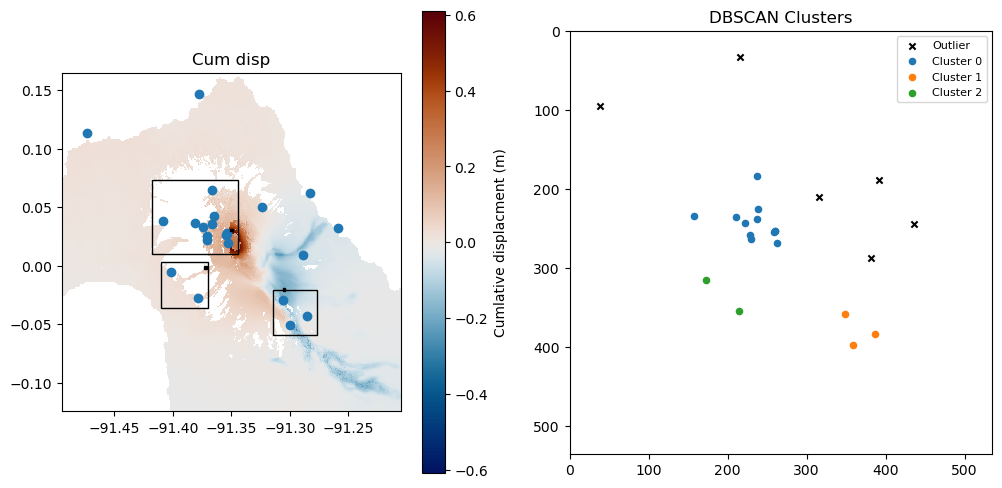

In [ ]:
# Filter points to only those in areas with SNR > Threshold value by removing rows
np.delete(coordinates_all,coords_snr<SNRThresh,0)
np.delete(YrsFound,coords_snr<SNRThresh,0)
eps_dist_km = 2
eps_dist = round((eps_dist_km*1000)/spatialRes_m)
WS = 5 # Window size for mean TS

# Spatially cluster spatial peaks using DBSCAN to detect inliers
DBSCAN_Clusts = DBSCAN(eps=eps_dist,min_samples=2,metric='euclidean').fit(coordinates_all)

# Visualise DBSCAN results
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 6)
)
ny, nx = CumDisp.shape
pcm = ax1.pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
cbar = plt.colorbar(pcm)
cbar.set_label("Cumlative displacment (m)")
ax1.set_title('Cum disp')
ax1.set_aspect("equal")
xLim = ax1.get_xlim
yLim = ax1.get_ylim
ax1.scatter(lon[coordinates_all[:, 1]], lat[coordinates_all[:, 0]])

labels = DBSCAN_Clusts.labels_
unique_labels = np.unique(labels)

Clust_StartYr = np.empty(shape=unique_labels.shape[0]-1)
Clust_EndYr = Clust_StartYr.copy()
ChosenTS = []
ChosenTS_Days = []
ChosenTS_Yrs = []
ClusterBufferM = 1000
numPix_ClustBuff = round(ClusterBufferM / spatialRes_m)
for label in unique_labels:

    mask = labels == label

    if label == -1:
        # Noise / outliers
        ax2.scatter(
            coordinates_all[mask, 1],
            coordinates_all[mask, 0],
            c='k',
            marker='x',
            s=20,
            label='Outlier'
        )
    else:
        ax2.scatter(
            coordinates_all[mask, 1],
            coordinates_all[mask, 0],
            s=20,
            label=f'Cluster {label}'
        )

        Clust_StartYr[label] = np.min(YrsFound[mask,:])
        Clust_EndYr[label] = np.max(YrsFound[mask,:])

        if Clust_StartYr[label] == 0:
            TS_StartIdx = 0
        elif Clust_StartYr[label] == yrsQ[-1]:
            TS_StartIdx = LOS.shape[2]-1
        else:
            TS_StartIdx = idxYrs[yrsQ==Clust_StartYr[label]].item() # .item() to convert from one-element array to scalar

        if Clust_EndYr[label] == 0:
            TS_EndIdx = 0
        elif Clust_EndYr[label] == yrsQ[-1]:
            TS_EndIdx = LOS.shape[2]-1
        else:
            TS_EndIdx = idxYrs[yrsQ==Clust_EndYr[label]].item()

        Xmin = np.min(coordinates_all[mask, 1]) - round(numPix_ClustBuff / 2)
        Xmax = np.max(coordinates_all[mask, 1]) + round(numPix_ClustBuff / 2)
        Ymin = np.min(coordinates_all[mask, 0]) - round(numPix_ClustBuff / 2)
        Ymax = np.max(coordinates_all[mask, 0]) + round(numPix_ClustBuff / 2)

        Wid = lon[Xmax] - lon[Xmin]
        Hei = lat[Ymax] - lat[Ymin]
        rect = mpatches.Rectangle((lon[Xmin],lat[Ymin]),Wid,Hei,linewidth=1, edgecolor='k', facecolor='none')
        ax1.add_patch(rect)

        LOS_sub = LOS[Ymin:Ymax+1, Xmin:Xmax+1, :]
        dlos = np.squeeze(LOS_sub[:, :, TS_EndIdx]) - np.squeeze(LOS_sub[:, :, TS_StartIdx])
        kernel = np.ones((WS, WS)) / WS**2
        window_mean = convolve2d(dlos, kernel, mode='same', fillvalue=np.nan)

        # Window with largest absolute mean displacement
        iy, ix = np.unravel_index(
            np.nanargmax(np.abs(window_mean)),
            window_mean.shape
        )

        best_value = window_mean[iy, ix]
        best_xmin = Xmin + ix
        best_xmax = best_xmin + (WS-1)
        best_ymin = Ymin + iy
        best_ymax = best_ymin + (WS-1)

        Wid2 = lon[best_xmin] - lon[best_xmax]
        Hei2 = lat[best_ymin] - lat[best_ymax]

        # Plot best rectangle used for timeseries
        rect2 = mpatches.Rectangle((lon[best_xmin],lat[best_ymin]),Wid2,Hei2,linewidth=1, edgecolor='k', facecolor='k')
        ax1.add_patch(rect2)

        # Extract timeseries
        Region = LOS[best_ymin:best_ymax+1, best_xmin:best_xmax+1, TS_StartIdx:TS_EndIdx+1]
        mean_ts = np.nanmean(Region, axis=(0, 1))
        # make mean_ts relative
        mean_ts = mean_ts - mean_ts[0]

        ChosenTS_Yrs.append(DatesDT[TS_StartIdx:TS_EndIdx+1])
        ChosenTS_Days.append(days_[TS_StartIdx:TS_EndIdx+1])
        ChosenTS.append(mean_ts)
        

ax2.set_xlim(0, nx)
ax2.set_ylim(ny, 0)
ax2.set_title('DBSCAN Clusters')
ax2.set_aspect('equal')
ax2.legend(loc='best', fontsize=8)

## Methods - Timeseries - Filtering

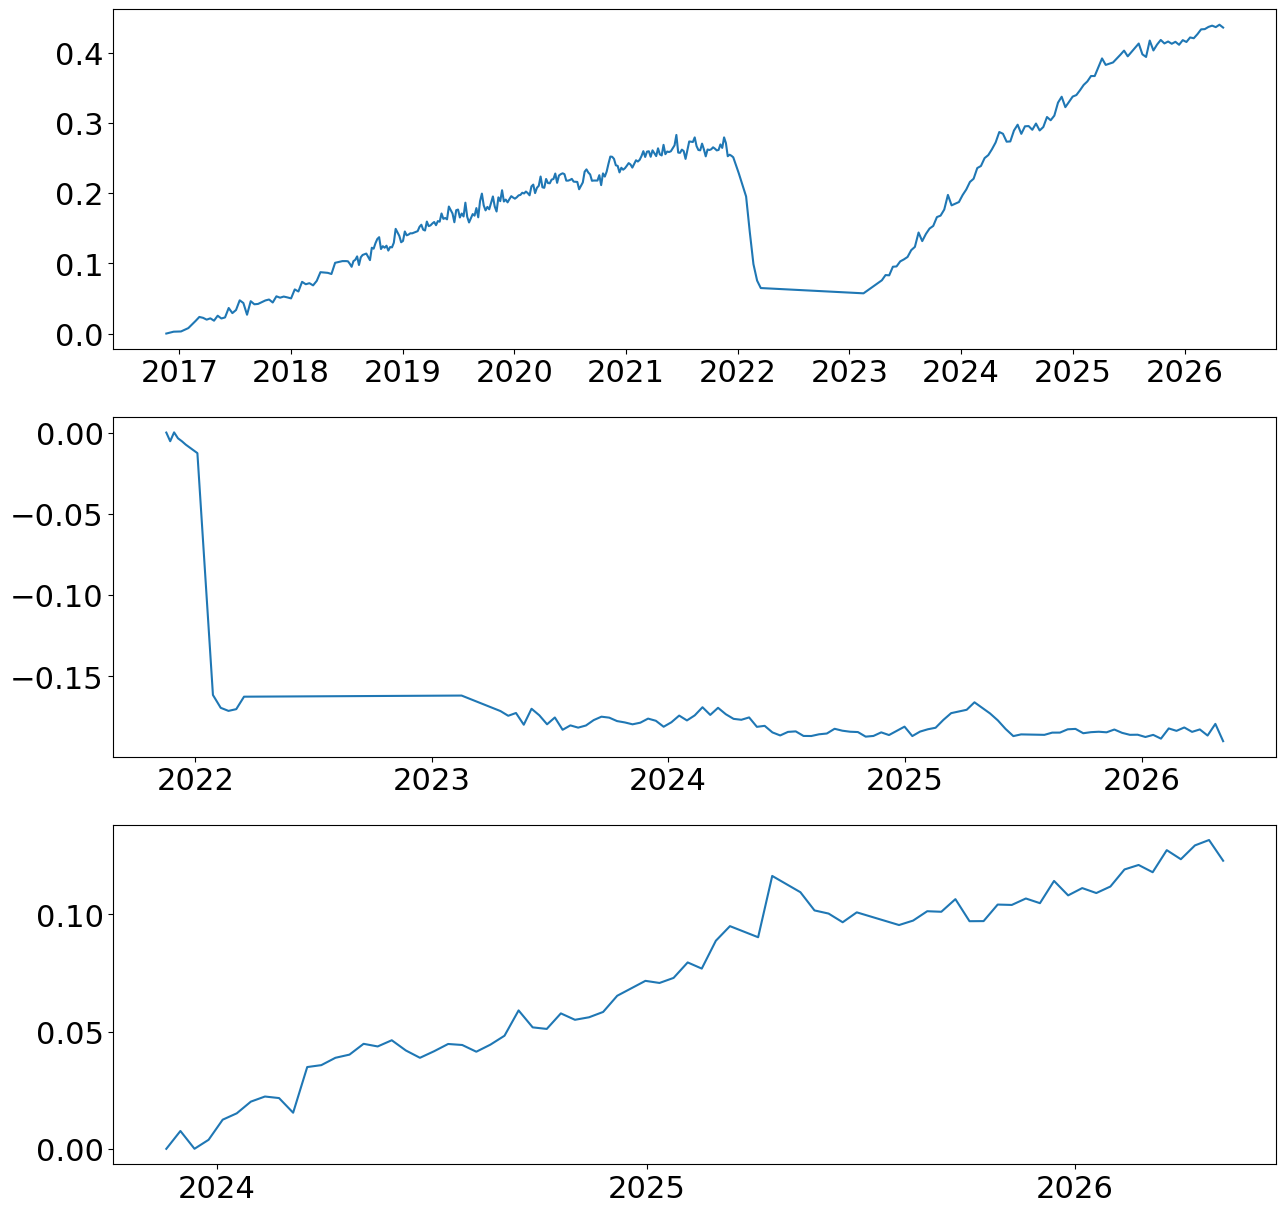

In [15]:
# Plot chosen timeseries
fig, axs = plt.subplots(len(ChosenTS),1, figsize=(15,15))

for k in range(len(ChosenTS)):
    axs[k].plot(ChosenTS_Yrs[k], ChosenTS[k], "-")
    axs[k].xaxis.set_major_locator(mdates.YearLocator())
    axs[k].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axs[k].tick_params(axis='both', which='major', labelsize=22)

### Try range of methods to split up timeseries

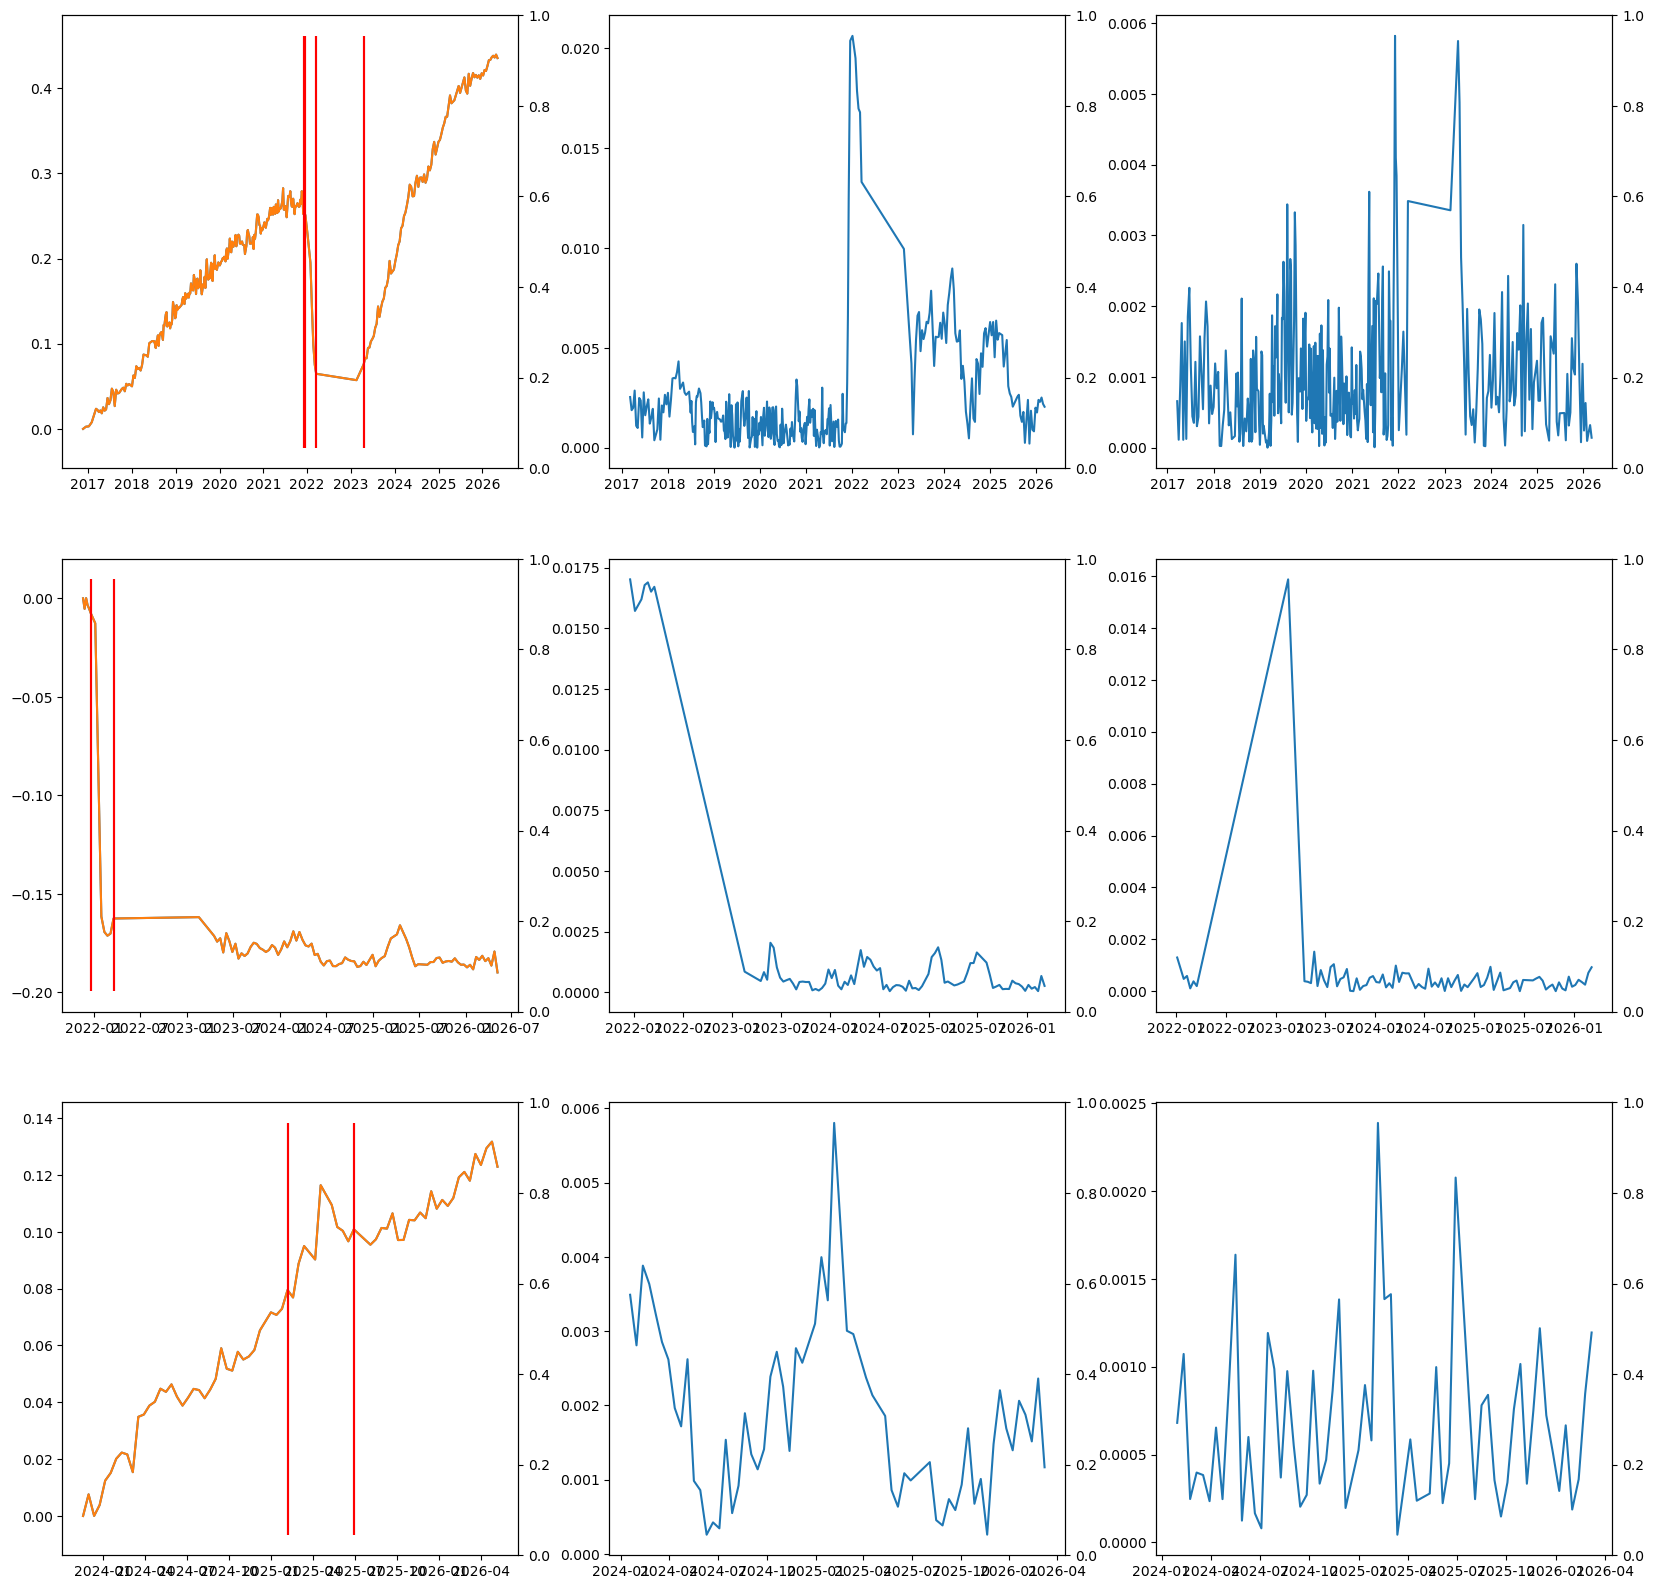

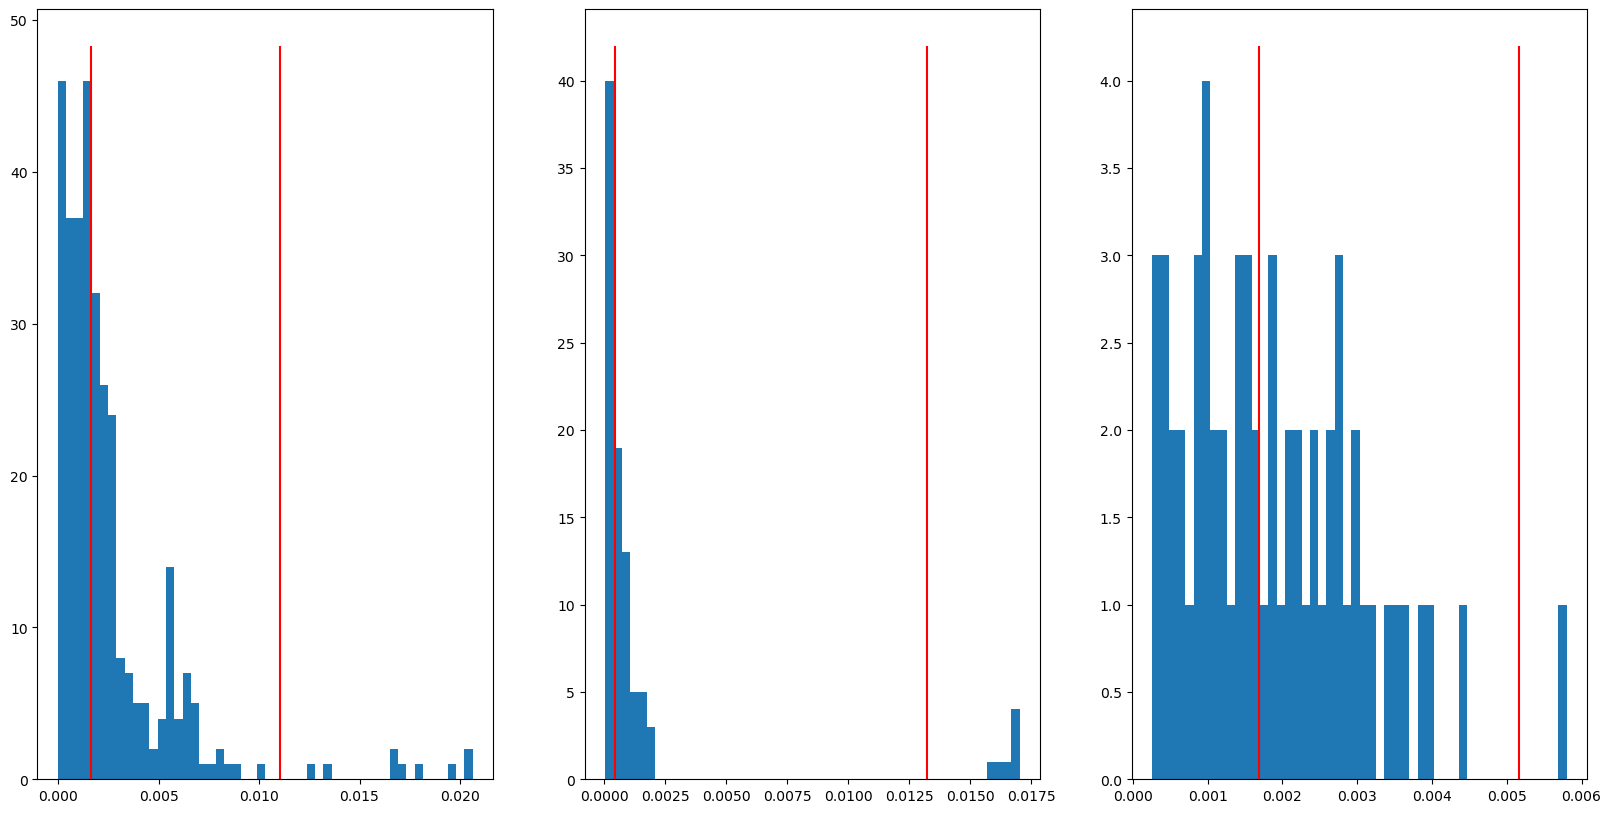

In [16]:
# Try CUSUM to detect change points in the timeseries
target = 0.1 # Target value (1 cm)
K = 0.005 # Reference value
TargetRate = 1 # cm/yr

def cusum(data, target, k):
    n = len(data)
    CP = np.zeros(n)
    for i in range(1, n):
        CP[i] = max(0, CP[i-1] + data[i] - target - k)
        #CN[i] = max(0, CN[i-1] - data[i] - target + k)
    return CP


numRows = 3
fig, ax2 = plt.subplots(len(ChosenTS),numRows, figsize=(20,20)) # For testing peaks
fig2, ax3 = plt.subplots(1,len(ChosenTS), figsize=(20,10)) # For histograms
Changes = []
for k in range(len(ChosenTS)):
    AllIdx = []
    # Try plotting second derivative and filtering
    FiltSize = 10
    mean_kernel = np.full((FiltSize), 1/FiltSize)
    smooth_signal = np.convolve(ChosenTS[k], mean_kernel,
                              mode='valid')

    FirstOrderDiff = np.diff(smooth_signal)
    SecondOrderDiff = np.diff(smooth_signal,n=2)
    ThirdOrderDiff = np.diff(smooth_signal,n=3)

    SDev = np.std(np.abs(FirstOrderDiff))
    SDev2 = np.std(np.abs(SecondOrderDiff))
    Idx_Anomalies = np.where(np.abs(FirstOrderDiff)>np.median(np.abs(FirstOrderDiff))+3*SDev)[0] # Calculate anomalies
    Idx_Anomalies2 = np.where(np.abs(SecondOrderDiff)>np.median(np.abs(SecondOrderDiff))+3*SDev2)[0] 

    if len(Idx_Anomalies) == 0:
        starts = np.array([], dtype=int)
        ends = np.array([], dtype=int)
    else:
        breaks = np.where(np.diff(Idx_Anomalies) > 1)[0]

        starts = np.r_[Idx_Anomalies[0], Idx_Anomalies[breaks + 1]]
        ends   = np.r_[Idx_Anomalies[breaks], Idx_Anomalies[-1]]

        # Remove isolated anomalies (groups of length 1)
        keep = starts != ends

        starts = starts[keep]
        ends = ends[keep]

    if len(Idx_Anomalies2) == 0:
        starts2 = np.array([], dtype=int)
        ends2 = np.array([], dtype=int)
    else:
        breaks2 = np.where(np.diff(Idx_Anomalies2) > 1)[0]

        starts2 = np.r_[Idx_Anomalies2[0], Idx_Anomalies2[breaks2 + 1]]
        ends2   = np.r_[Idx_Anomalies2[breaks2], Idx_Anomalies[-1]]

        # Remove isolated anomalies (groups of length 1)
        keep2 = starts2 != ends2

        starts2 = starts2[keep2]
        ends2 = ends2[keep2]

    #ax2[k,2].plot(ChosenTS_Days[k], smoothed_1D*365.25, "-") # To put into m/yr
    # ax2[k,1].plot(ChosenTS_Yrs[k][0:-1], smoothed_1D_diff*365.25, "-")
    # ax2[k,2].plot(ChosenTS_Days[k], diff_filter_res2, "-")
    start_index = (FiltSize - 1) // 2
    end_index = start_index + len(smooth_signal)

    starts = np.round(starts + FiltSize/2).astype(int)
    ends = np.round(ends + FiltSize/2).astype(int)
    starts2 = np.round(starts2 + (FiltSize+1)/2).astype(int)
    ends2 = np.round(ends2 + (FiltSize+1)/2).astype(int)

    AllIdx.extend(starts)
    AllIdx.extend(ends)
    AllIdx.extend(starts2)
    AllIdx.extend(ends2)

    Change_Idx = np.unique(AllIdx).astype(int)
    Changes.append(Change_Idx)

    ax2[k,0].plot(ChosenTS_Yrs[k], ChosenTS[k], "-")
    ax2[k,0].plot(ChosenTS_Yrs[k], ChosenTS[k], "-")
    Bot, Top = ax2[k,0].get_ylim()
    ax2[k,0].vlines(ChosenTS_Yrs[k][Change_Idx],Bot,Top,colors='r')
    ax2[k,0].vlines(ChosenTS_Yrs[k][Change_Idx],Bot,Top,colors='r')
    # ax2[k,0].vlines(ChosenTS_Yrs[k][starts2],Bot,Top,colors='y')
    # ax2[k,0].vlines(ChosenTS_Yrs[k][ends2],Bot,Top,colors='y')

    ax2[k,1].plot(ChosenTS_Yrs[k][start_index+1:end_index], np.abs(FirstOrderDiff), "-")
    ax2[k,2].plot(ChosenTS_Yrs[k][start_index+2:end_index], np.abs(SecondOrderDiff), "-")
    #ax2[k,2].plot(ChosenTS_Days[k][1:-2], ThirdOrderDiff, "-")

    ax2R = ax2[k,0].twinx()
    ax2R2 = ax2[k,1].twinx()
    ax2R3 = ax2[k,2].twinx()

    Test=1

    # Try cusum
    # CP = cusum(abs(smoothed_1D_diff), target, K)

    # Rates = np.abs(FirstOrderDiff / ChosenTS_Days[k][start_index+1:end_index])
    # ax2R.set_ylabel('Rate', color='r')
    # ax2R.plot(ChosenTS_Yrs[k][start_index+1:end_index],Rates,color='r')

    # Try finding peaks
    # Peak_Idx_Pos = find_peaks(smoothed_1D_diff*365.25,height=0.2)
    # Peak_Idx_Neg = find_peaks(-smoothed_1D_diff*365.25,height=0.2)
    # ymin = np.min(smoothed_1D*365.25)
    # ymax = np.max(smoothed_1D*365.25)
    # ax2[k,1].vlines(ChosenTS_Yrs[k][Peak_Idx_Pos[0]],ymin,ymax)
    # ax2[k,1].vlines(ChosenTS_Yrs[k][Peak_Idx_Neg[0]],ymin,ymax)
    # Med_1D = np.median(smoothed_1D_diff*365.25)
    # Anom_Idx_Pos = np.where(smoothed_1D_diff*365.25 > 3*Med_1D)
    # ax2[k,1].hlines(Med_1D,np.min(ChosenTS_Yrs[k][0:-1]),np.max(ChosenTS_Yrs[k][0:-1]))
    # ax2[k,1].hlines(3*Med_1D,np.min(ChosenTS_Yrs[k][0:-1]),np.max(ChosenTS_Yrs[k][0:-1]))
    # ax2[k,1].vlines(ChosenTS_Yrs[k][Anom_Idx_Pos],0,0.2)

    ax3[k].hist(np.abs(FirstOrderDiff),50)
    HighPoint = np.percentile(np.abs(FirstOrderDiff),97.5)
    Bot, Top = ax3[k].get_ylim()
    ax3[k].vlines(np.median(np.abs(FirstOrderDiff)),Bot,Top,colors='r')
    ax3[k].vlines(np.median(np.abs(FirstOrderDiff))+3*SDev,Bot,Top,colors='r')

    # ax3[k].hist(np.abs(SecondOrderDiff),50)
    # HighPoint = np.percentile(np.abs(SecondOrderDiff),97.5)
    # Bot, Top = ax3[k].get_ylim()
    # ax3[k].vlines(np.median(np.abs(SecondOrderDiff)),Bot,Top,colors='r')
    # ax3[k].vlines(np.median(np.abs(SecondOrderDiff))+3*SDev2,Bot,Top,colors='r')


Text(0.5, 0.98, 'Filtering')

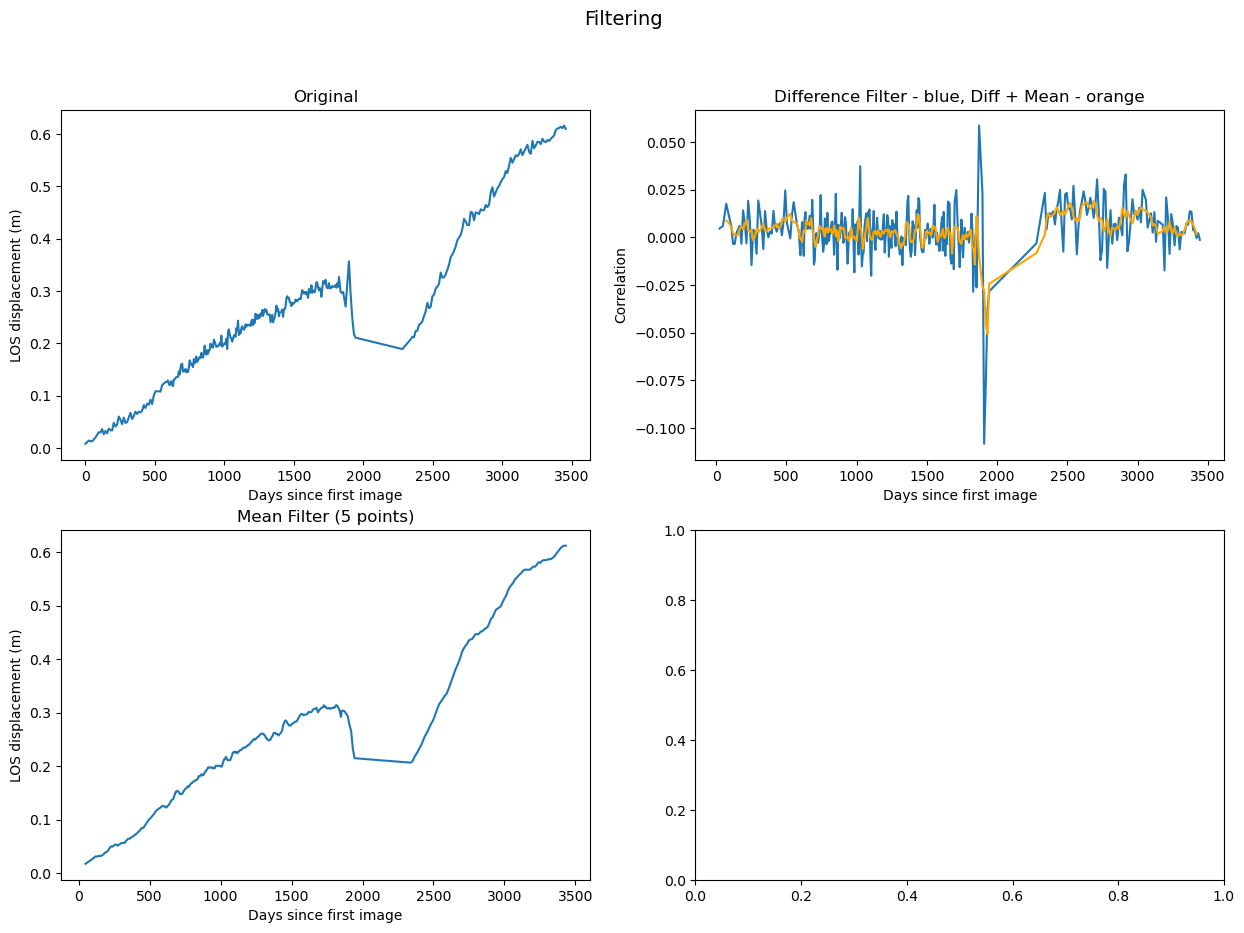

In [17]:
# Plot timeseries
fig, axs = plt.subplots(2,2, figsize=(15, 10))
pixTS = LOS[Idx_MaxD_Lat, Idx_MaxD_Lon, :]
axs[0,0].plot(days_, pixTS, "-")
axs[0,0].set_xlabel("Days since first image")
axs[0,0].set_ylabel("LOS displacement (m)")
axs[0,0].set_title("Original")

# Mean filter
FiltSize = 5
mean_kernel = np.full((FiltSize,), 1/FiltSize)
smooth_signal3p = np.convolve(pixTS, mean_kernel,
                              mode='valid')
axs[1,0].plot(days_[2:-2], smooth_signal3p, "-")
axs[1,0].set_xlabel("Days since first image")
axs[1,0].set_ylabel("LOS displacement (m)")
axs[1,0].set_title("Mean Filter (5 points)")

# Difference filter
diff_filter_res= np.correlate(pixTS, np.array([-1, 0, 1]),
                           mode='valid')
double_diff_filter_res= np.convolve(diff_filter_res, mean_kernel,
                           mode='valid')
axs[0,1].plot(days_[1:-1], diff_filter_res, "-")
axs[0,1].plot(days_[3:-3], double_diff_filter_res, "-", color="orange")
axs[0,1].set_xlabel("Days since first image")
axs[0,1].set_ylabel("Correlation")
axs[0,1].set_title("Difference Filter - blue, Diff + Mean - orange")

# Combined mean and difference filter
fig.suptitle("Filtering", fontsize=14)

## Methods - Change point detection

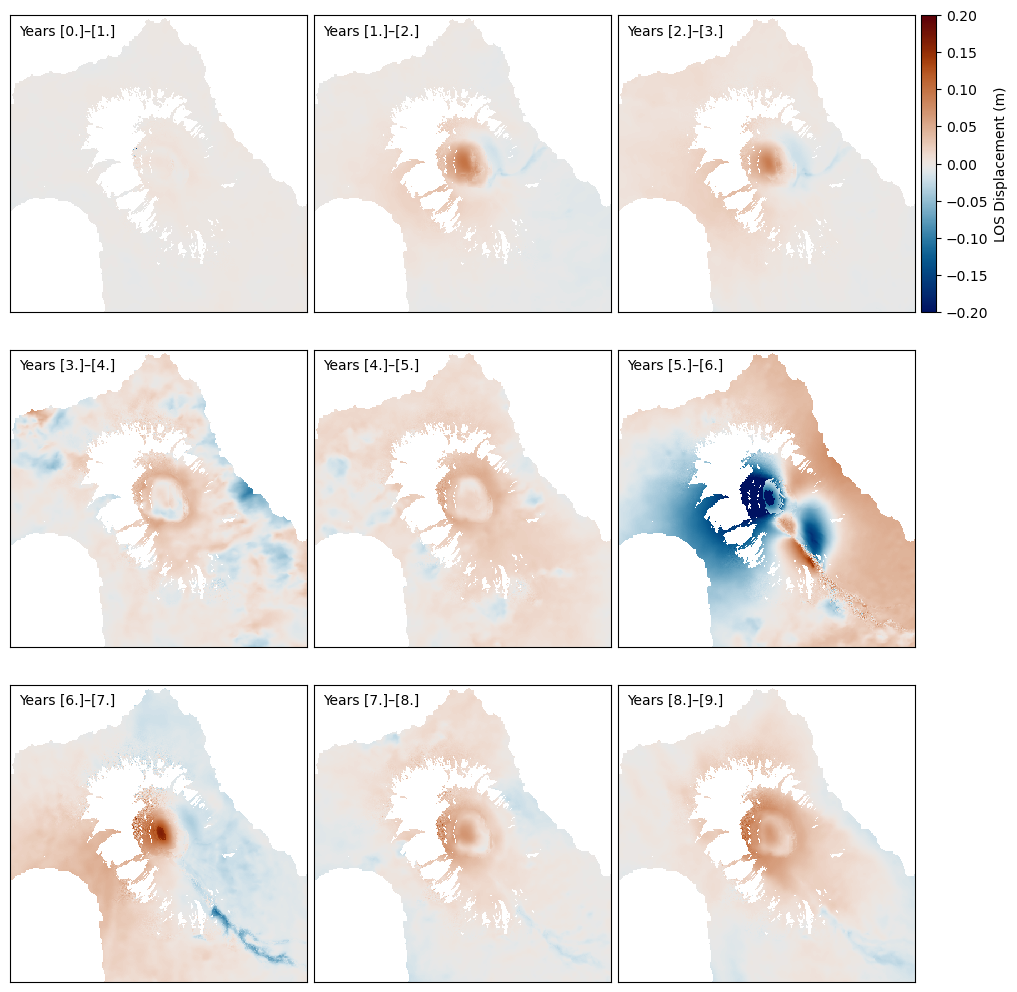

In [18]:
numCols = 3
numRows = 3

fig, axs = plt.subplots(
    numRows,
    numCols,
    figsize=(10, 10),
    constrained_layout=True
)
axs = np.atleast_2d(axs)

# Global colour limits
vmax = np.nanmax(np.abs(CumDisp))
for k in range(len(yrsQ)):
    vmax = max(
        vmax,
        np.nanmax(np.abs(LOS[:, :, TimeIdxInc[k]] - LOS[:, :, StartIdx[k]]))
    )

nplots = len(yrsQ)
pcm_cb = None

for k in range(nplots):

    i, j = divmod(k, numCols)
    ax = axs[i, j]

    if k == len(yrsQ):
        continue
    else:
        Disp = LOS[:, :, TimeIdxInc[k]] - LOS[:, :, StartIdx[k]]
        title = f"Years {StartYr[k]+1}–{EndYr[k]+1}"
        x = Lon[RowIdxInc[k], ColIdxInc[k]]
        y = Lat[RowIdxInc[k], ColIdxInc[k]]

    pcm = ax.pcolormesh(
        Lon,
        Lat,
        Disp,
        shading="auto",
        cmap=cm.vik,
        vmin=-0.2,
        vmax=0.2,
    )
    ax.set_box_aspect(1)

    # Title inside axes
    ax.text(
        0.03, 0.97, title,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(fc="white", ec="none", alpha=0.7)
    )

    # Remove all axes clutter
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Save top-right plot for colorbar
    if i == 0 and j == numCols - 1:
        pcm_cb = pcm
        ax_cb = ax

# Hide unused panels
for k in range(nplots, numRows * numCols):
    axs.flat[k].set_visible(False)

# Single colorbar on top-right panel
cbar = fig.colorbar(
    pcm_cb,
    ax=ax_cb,
    fraction=0.05,
    pad=0.02
)
cbar.set_label("LOS Displacement (m)")

# Tighten spacing
fig.set_constrained_layout_pads(
    w_pad=0.01,
    h_pad=0.01,
    wspace=0.02,
    hspace=0.02
)

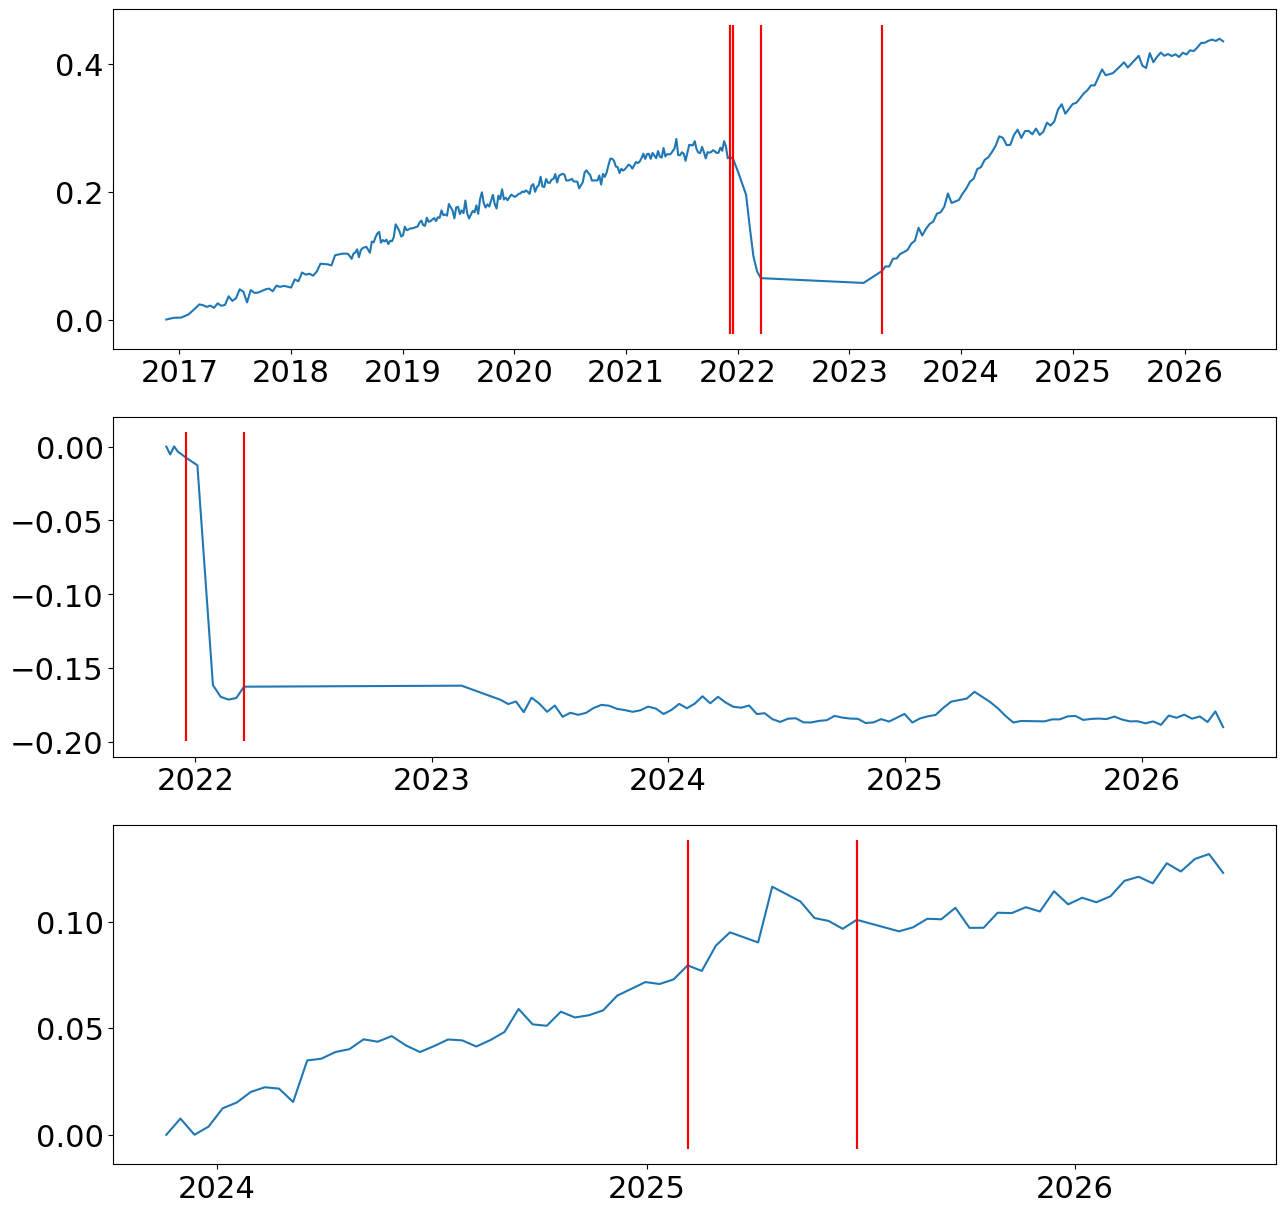

In [19]:
# Plot chosen timeseries
fig, axs = plt.subplots(len(ChosenTS),1, figsize=(15,15))

for k in range(len(ChosenTS)):
    axs[k].plot(ChosenTS_Yrs[k], ChosenTS[k], "-")
    Bot, Top = axs[k].get_ylim()
    axs[k].vlines(ChosenTS_Yrs[k][Changes[k]],Bot,Top,colors='r')
    axs[k].vlines(ChosenTS_Yrs[k][Changes[k]],Bot,Top,colors='r')
    axs[k].xaxis.set_major_locator(mdates.YearLocator())
    axs[k].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axs[k].tick_params(axis='both', which='major', labelsize=22)

Test=1